<a href="https://www.kaggle.com/code/omborse771924/automobile-market-analytics-dataset-eda?scriptVersionId=335113441" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitdfd ions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/deeplumiere/automobile-market-analytics-dataset/automobile_dataset.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/deeplumiere/automobile-market-analytics-dataset/automobile_dataset.csv')

In [3]:
df.head()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


In [4]:
df.tail()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
5495,Volkswagen,Tiguan,2022,Petrol,Automatic,NaN,29506,161.0,NaN,1,0.0,Partial Service,Black,SUV,AWD,33.0,GA,20333
5496,Nissan,Pathfinder,2006,Petrol,Automatic,3.1,287332,243.0,227.0,5,1.0,No Service,Gray,SUV,AWD,NaN,NY,500
5497,BMW,X3,2013,Petrol,Automatic,2.2,95961,171.0,152.0,2,1.0,No Service,Blue,SUV,AWD,32.0,MI,9882
5498,Volkswagen,Golf,2020,Hybrid,Automatic,1.5,56643,135.0,125.0,2,1.0,No Service,White,Hatchback,FWD,57.0,NY,10474
5499,Chevrolet,Tahoe,2011,Petrol,Automatic,2.1,169929,168.0,158.0,3,1.0,NaN,Gray,SUV,AWD,NaN,MI,6193


In [5]:
df.info

<bound method DataFrame.info of                Make       Model  Year Fuel_Type Transmission  Engine_Size  \
0     Mercedes-Benz         GLE  2024    Petrol    Automatic          2.3   
1           Hyundai      Tucson  2008    Petrol    Automatic          2.3   
2        Volkswagen        Golf  2021    Hybrid          NaN          1.9   
3         Chevrolet       Tahoe  2005    Petrol          NaN          2.2   
4            Toyota       Camry  2022    Petrol    Automatic          1.9   
...             ...         ...   ...       ...          ...          ...   
5495     Volkswagen      Tiguan  2022    Petrol    Automatic          NaN   
5496         Nissan  Pathfinder  2006    Petrol    Automatic          3.1   
5497            BMW          X3  2013    Petrol    Automatic          2.2   
5498     Volkswagen        Golf  2020    Hybrid    Automatic          1.5   
5499      Chevrolet       Tahoe  2011    Petrol    Automatic          2.1   

      Mileage  Horsepower  Torque  Owners  

In [6]:
df.describe()

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,4656.000000,5500.000000,4700.000000,4701.000000,5500.000000,4688.000000,4706.000000,5500.000000
mean,2014.494000,2.450623,114529.481636,198.236596,189.014678,2.464000,0.408063,34.179771,12319.873636
std,5.789745,0.843913,91858.943421,55.678165,56.631309,1.280022,0.491527,15.085473,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.000000,39112.000000,160.000000,151.000000,1.000000,0.000000,27.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,3.000000,172757.500000,231.000000,219.000000,3.000000,1.000000,37.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


In [7]:
df.isnull()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False
5496,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
5497,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5498,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Make                  0
Model                 0
Year                  0
Fuel_Type             0
Transmission        827
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Service_History     855
Color               803
Body_Type             0
Drivetrain            0
Fuel_Efficiency     794
Location            782
Selling_Price         0
dtype: int64

In [9]:
import pandas as pd

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical missing values with Median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with Mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check missing values
print(df.isnull().sum())

Make                0
Model               0
Year                0
Fuel_Type           0
Transmission        0
Engine_Size         0
Mileage             0
Horsepower          0
Torque              0
Owners              0
Accident_History    0
Service_History     0
Color               0
Body_Type           0
Drivetrain          0
Fuel_Efficiency     0
Location            0
Selling_Price       0
dtype: int64


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Engine_Size',
       'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History',
       'Service_History', 'Color', 'Body_Type', 'Drivetrain',
       'Fuel_Efficiency', 'Location', 'Selling_Price'],
      dtype='object')

## EDA

DATASET SHAPE
(5500, 18)


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      5500 non-null   object 
 5   Engine_Size       5500 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        5500 non-null   float64
 8   Torque            5500 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  5500 non-null   float64
 11  Service_History   5500 non-null   object 
 12  Color             5500 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   5500 non-null   float64


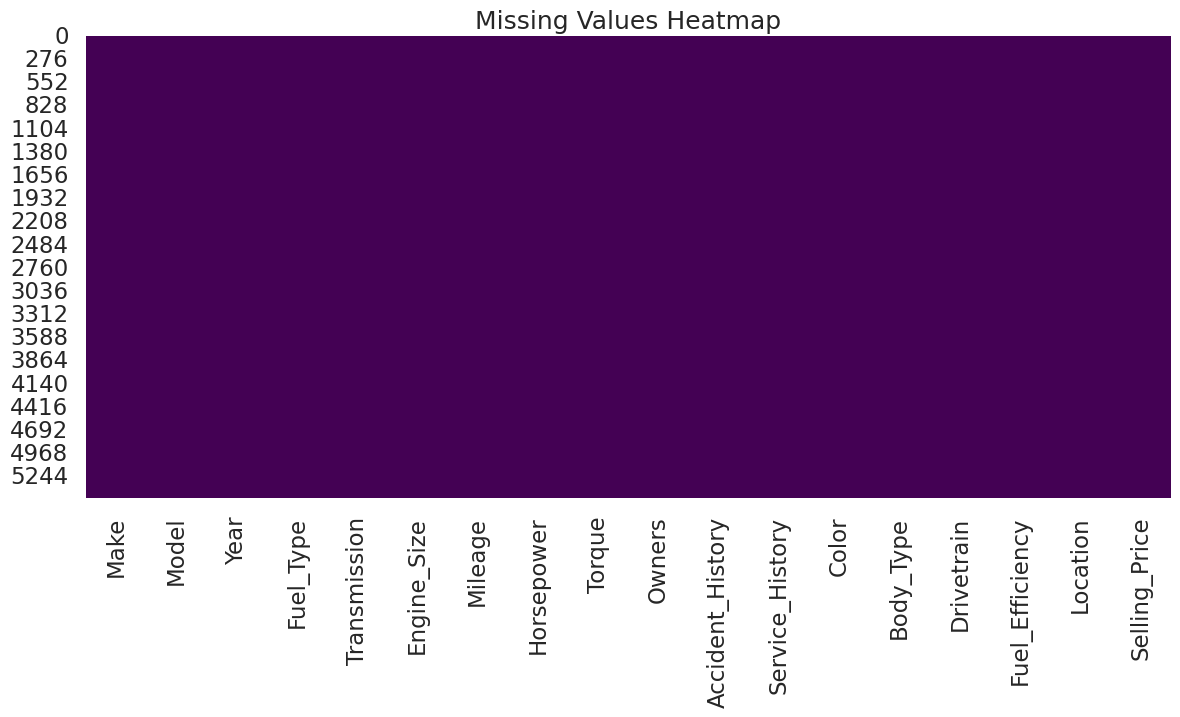

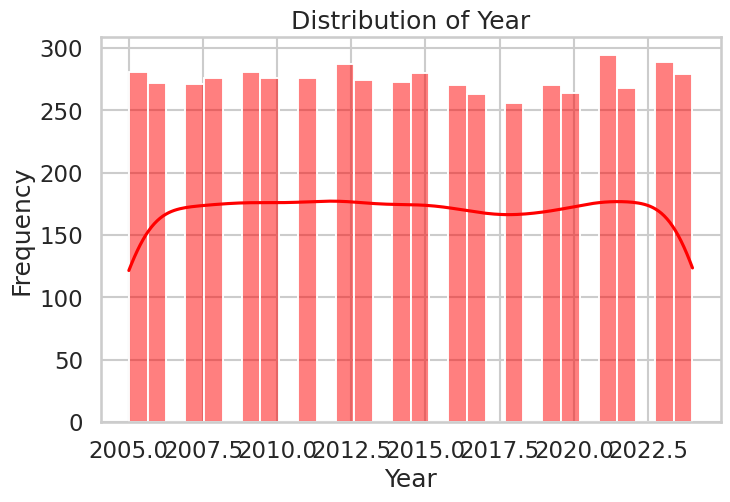

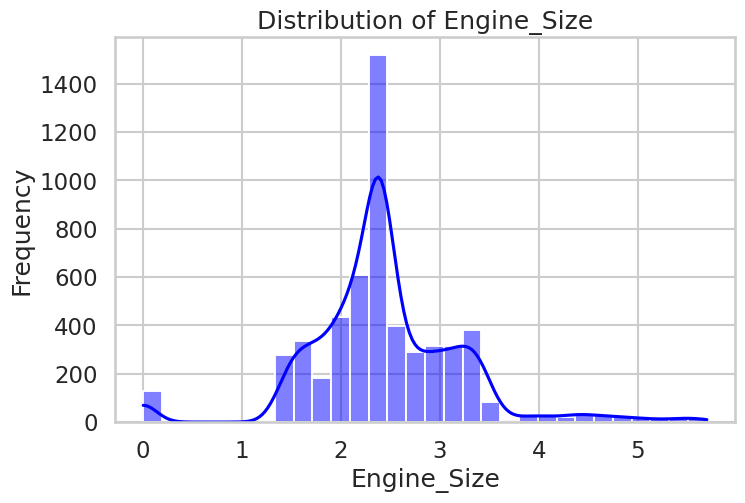

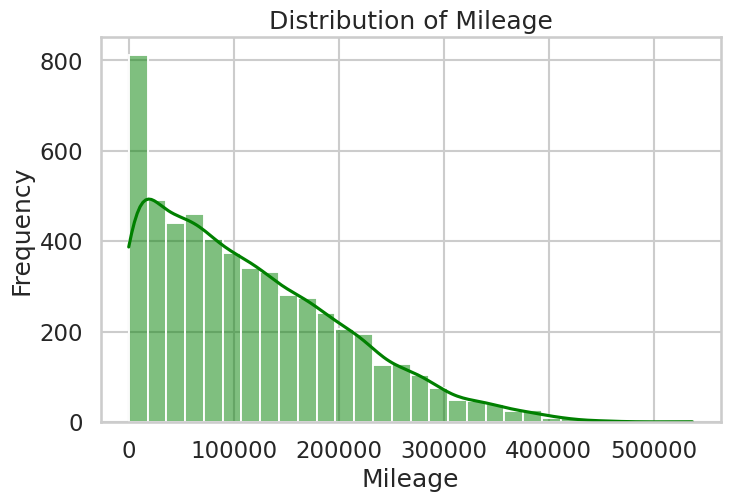

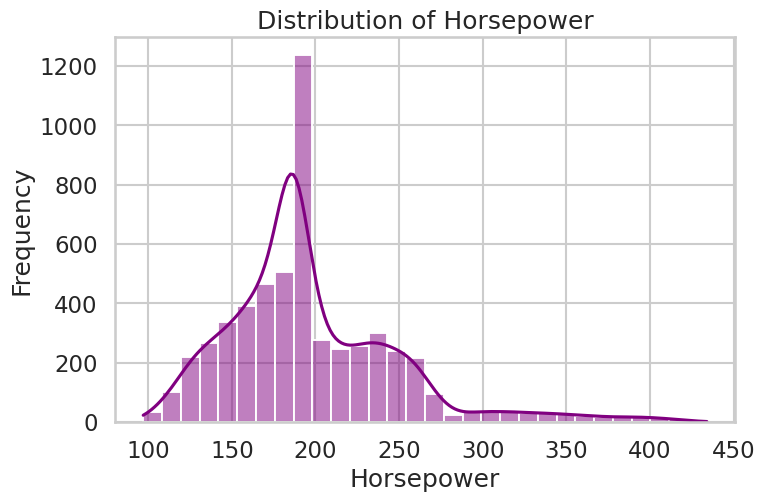

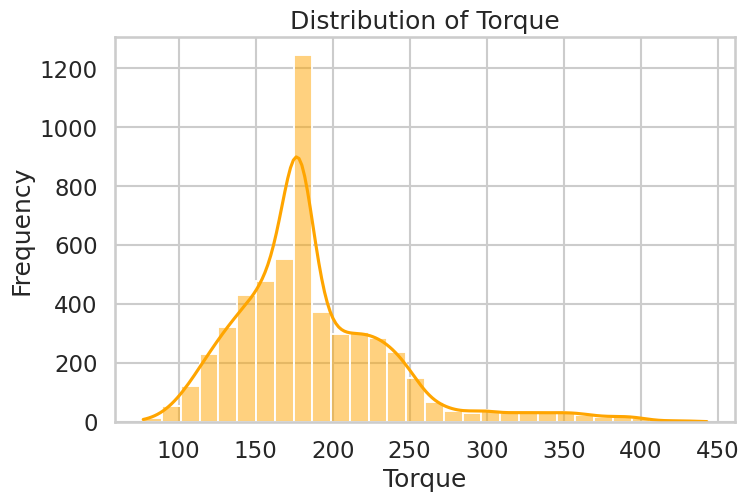

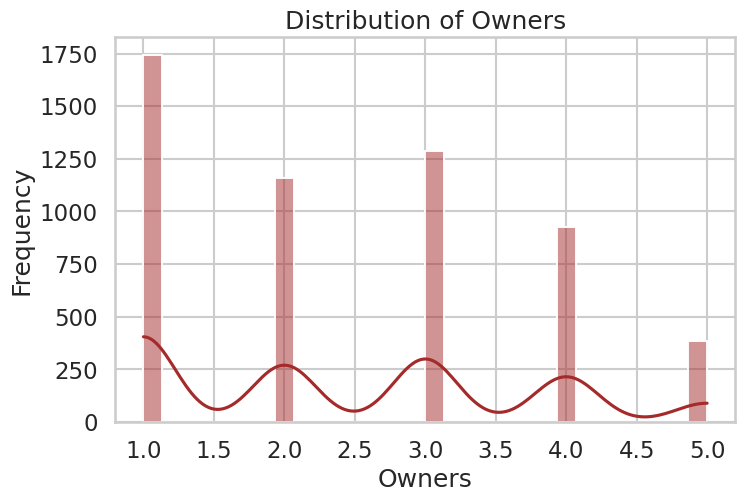

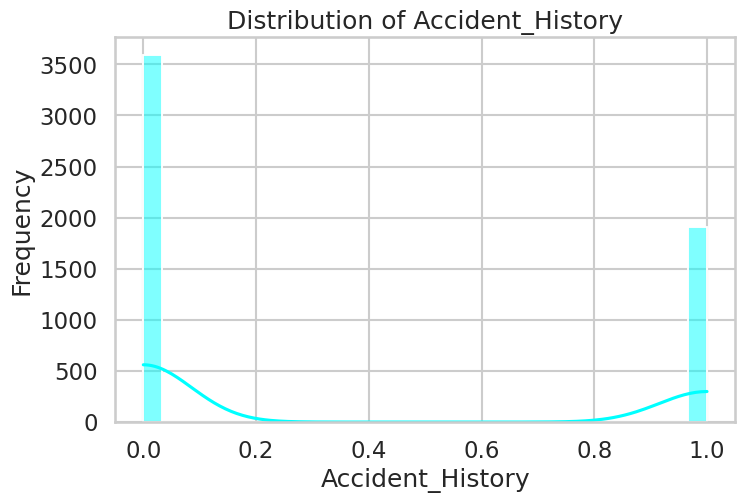

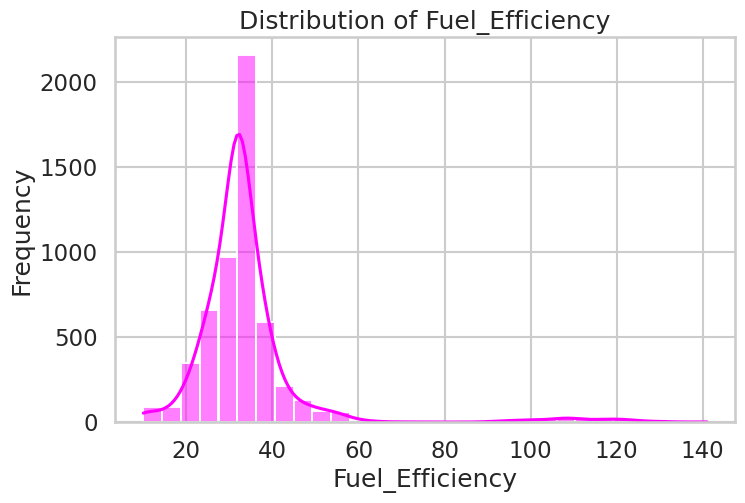

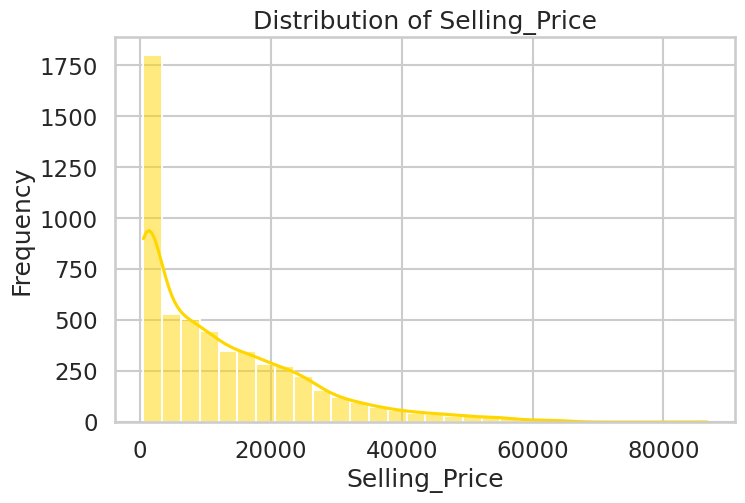

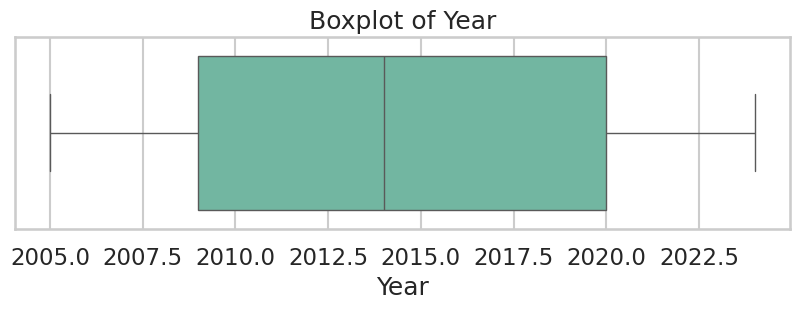

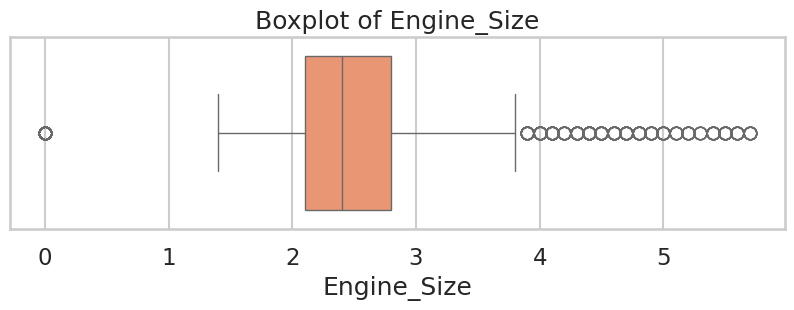

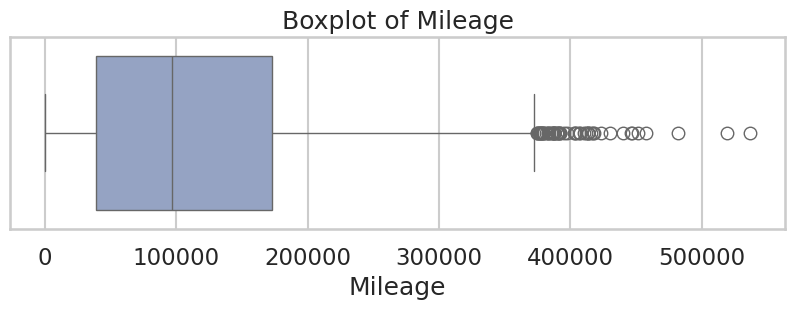

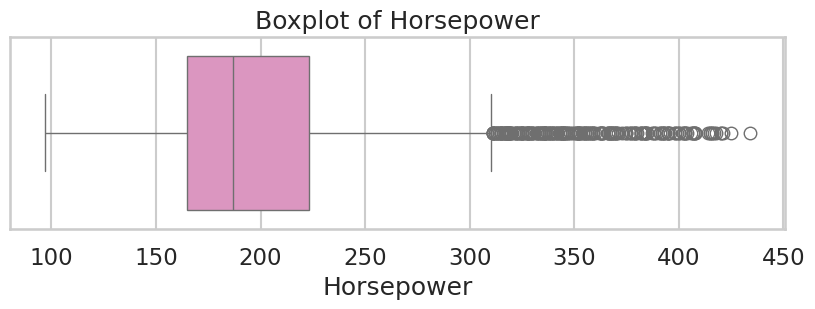

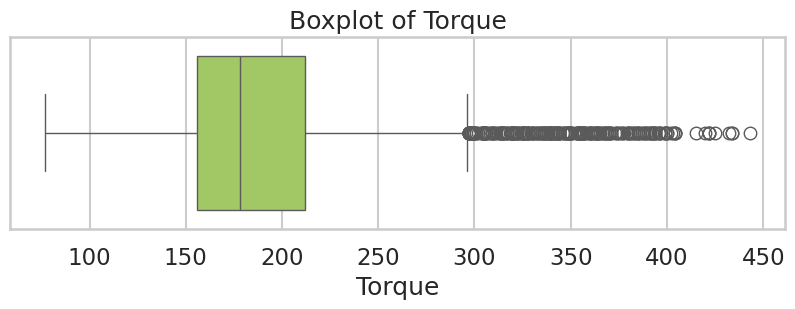

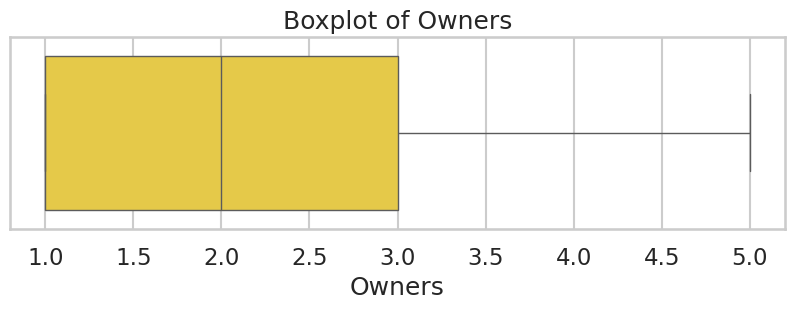

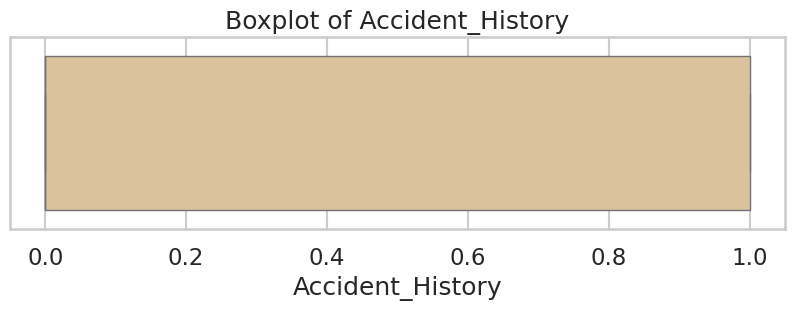

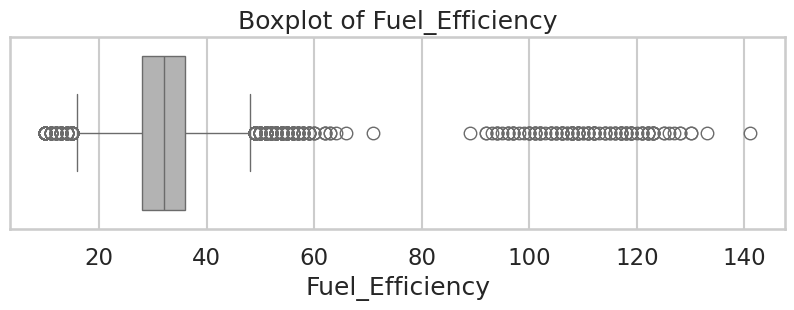

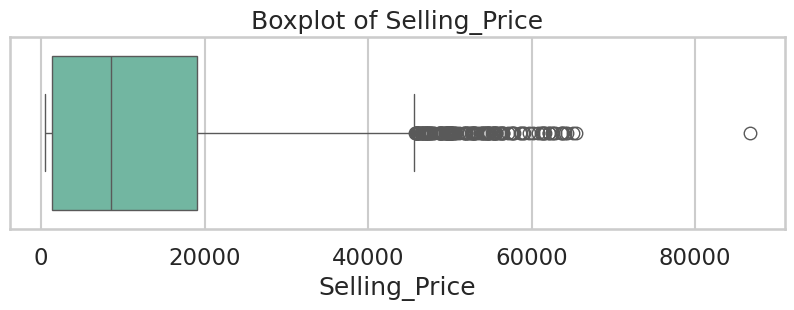

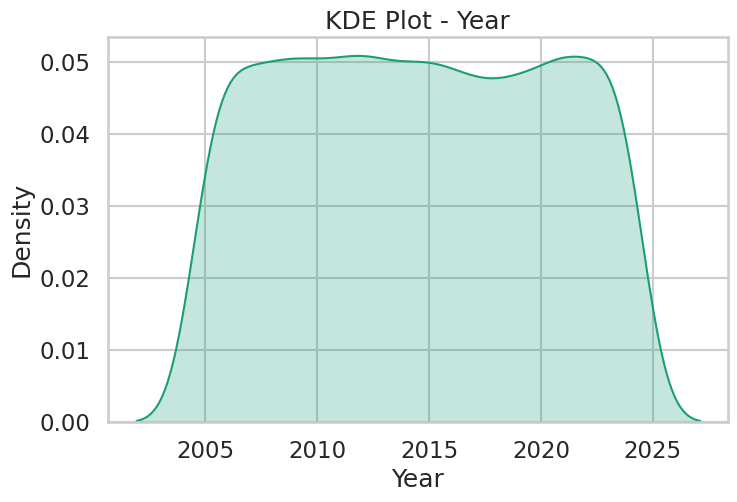

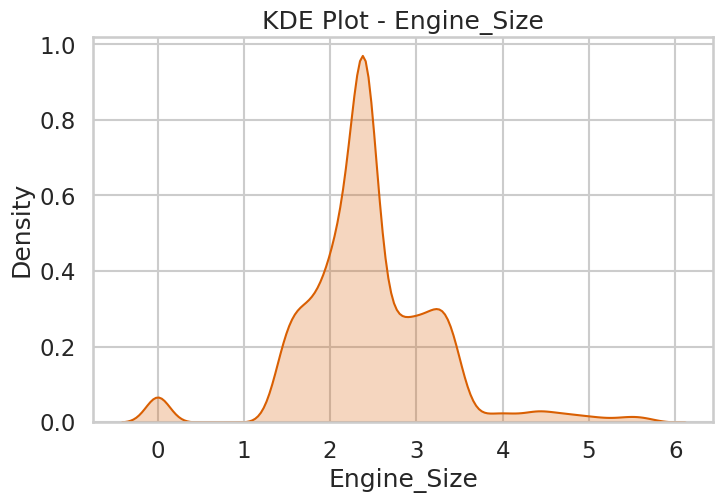

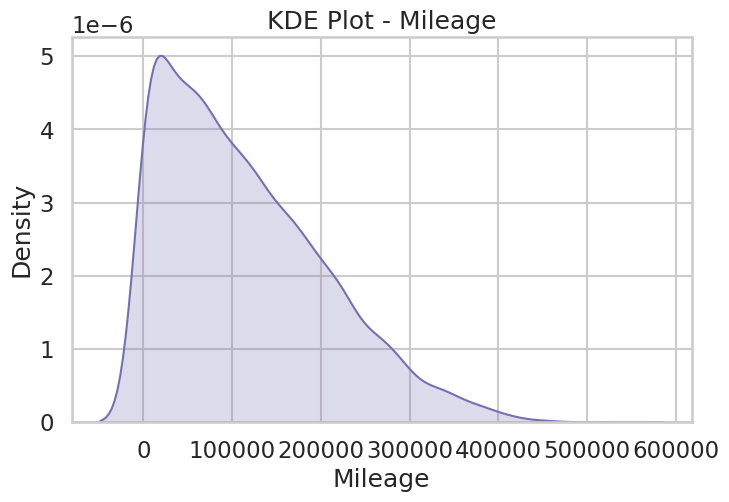

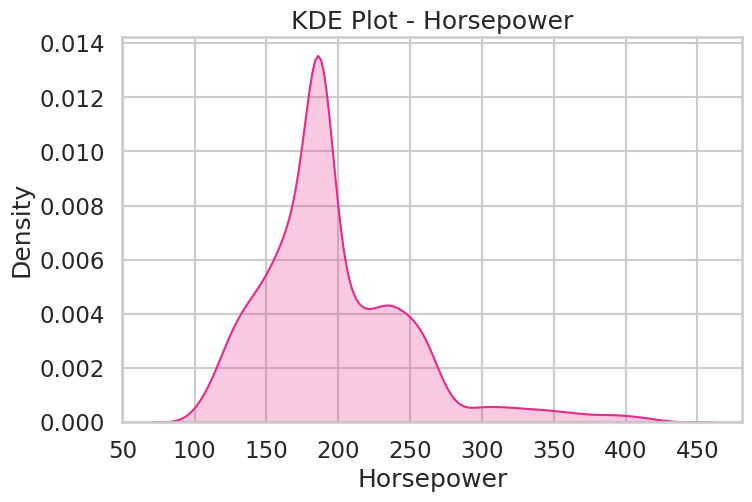

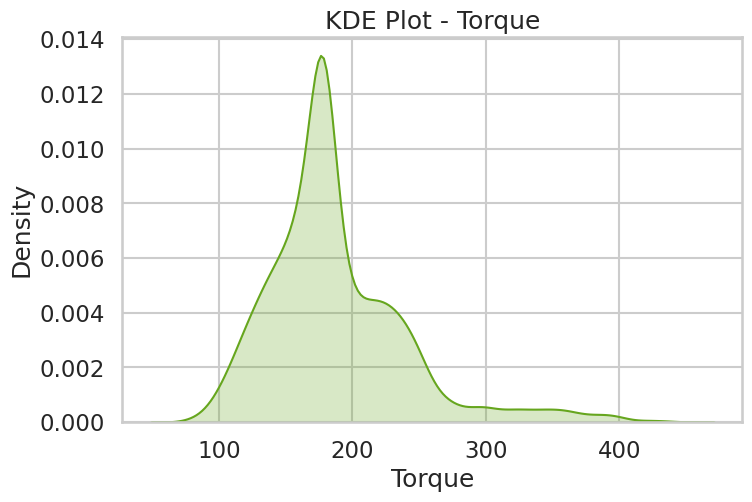

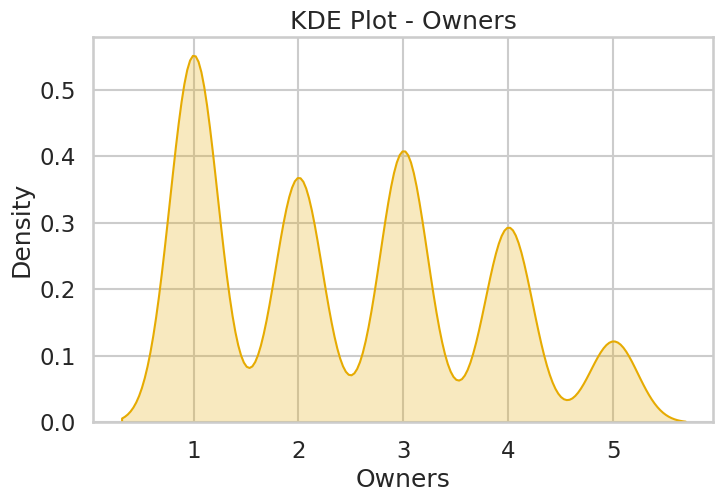

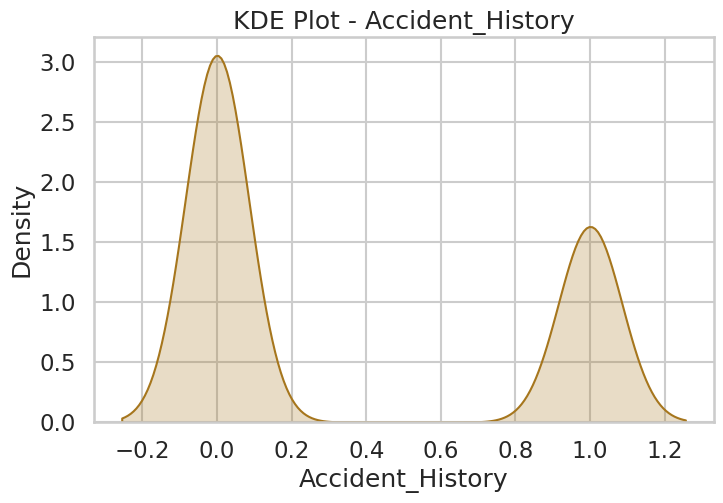

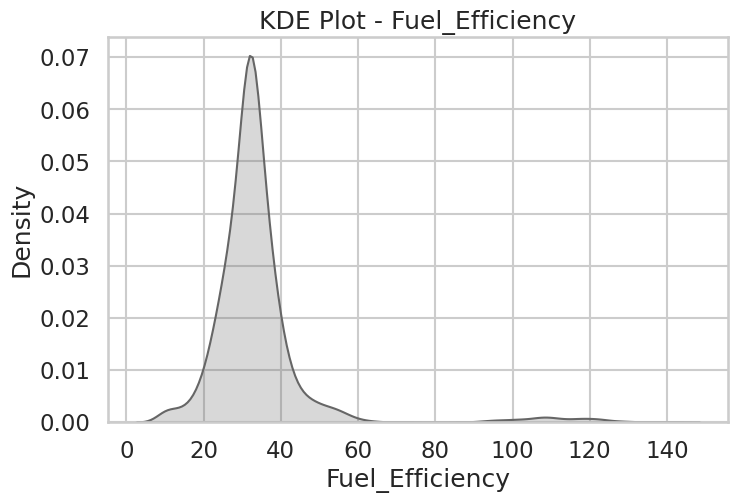

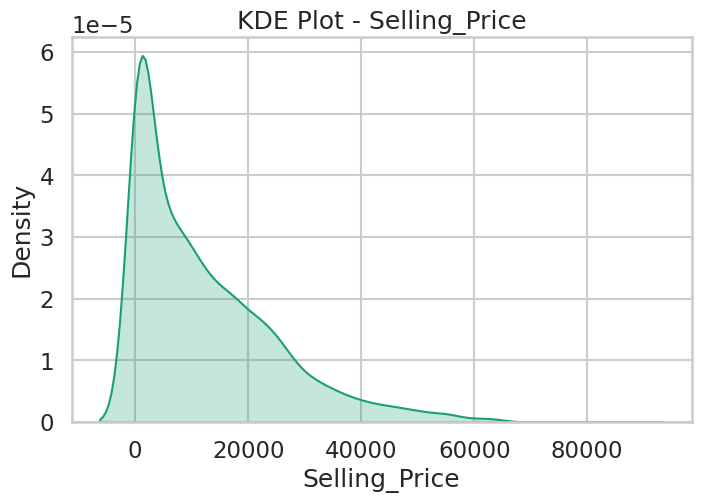

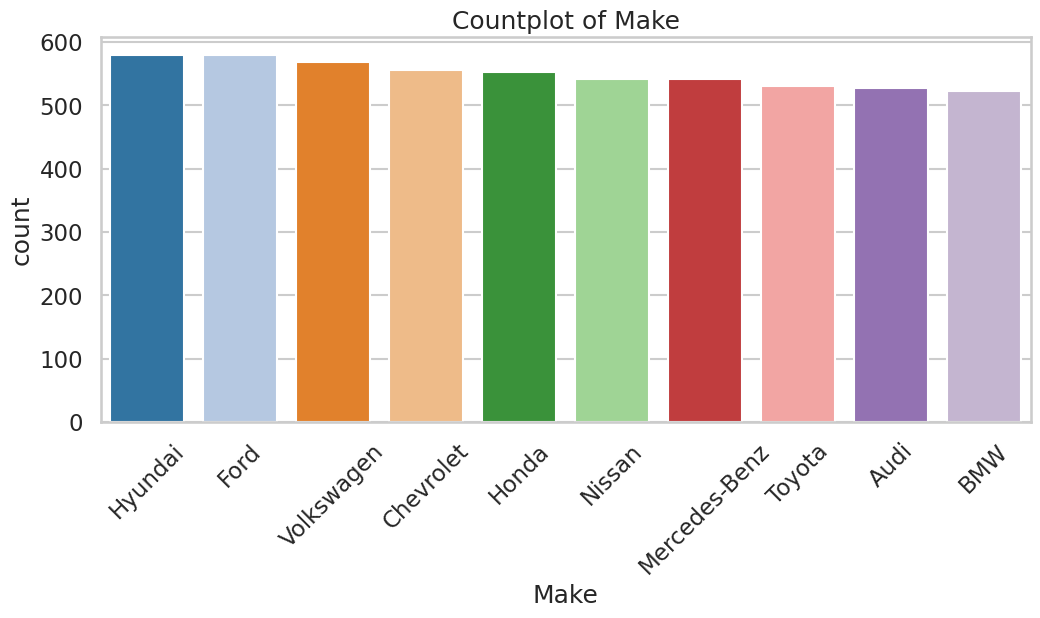

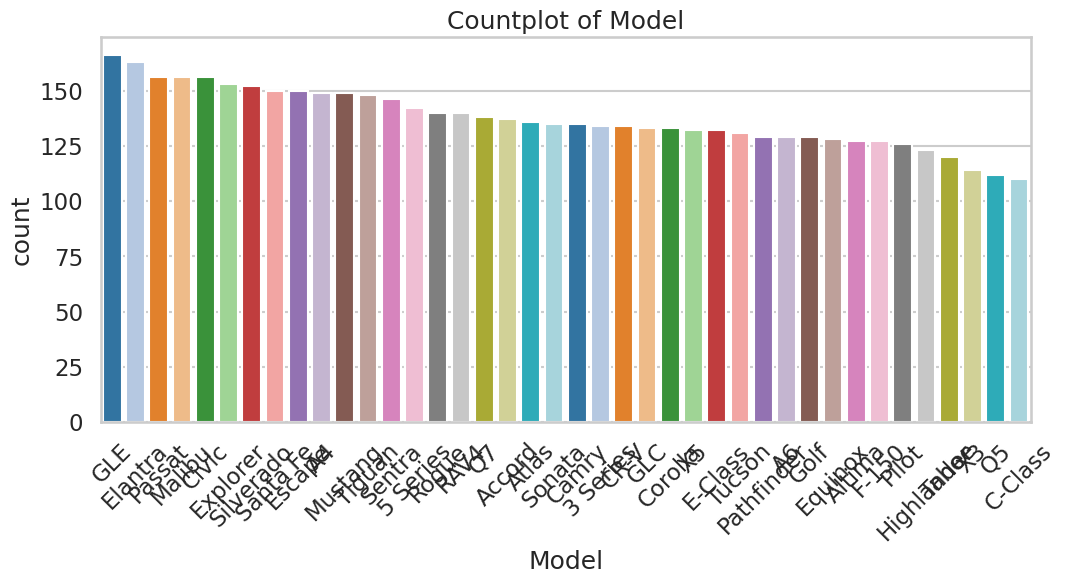

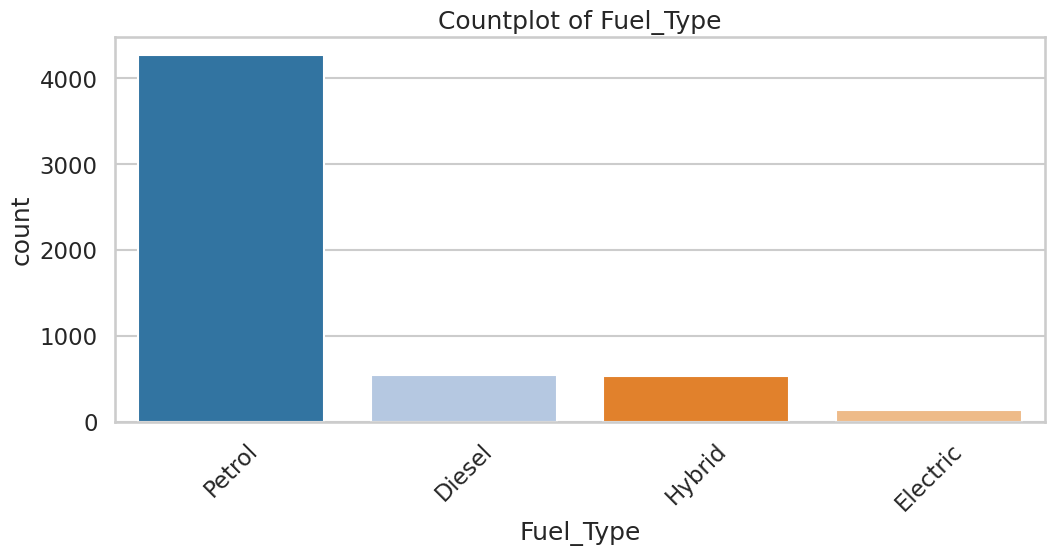

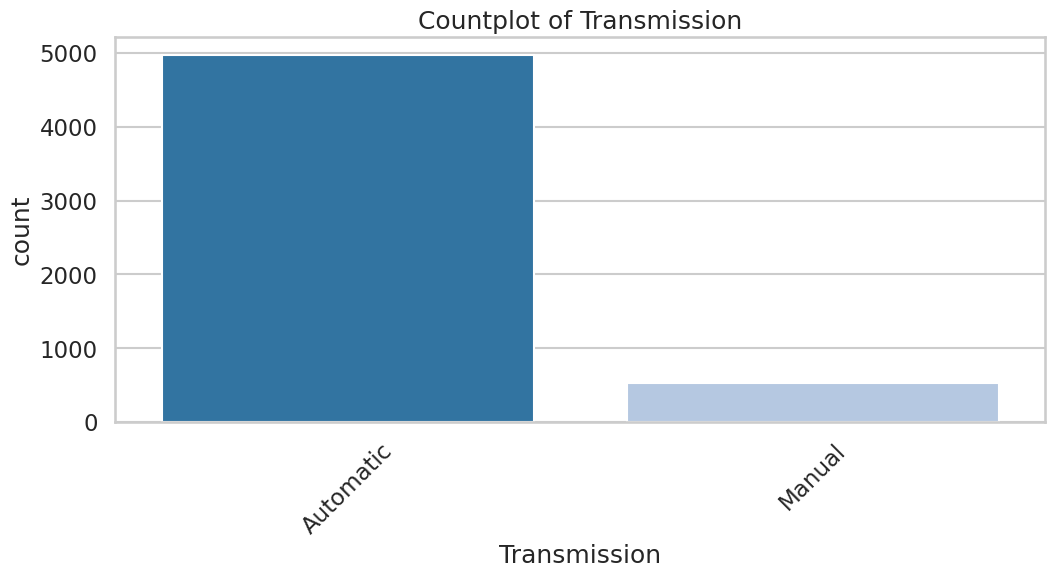

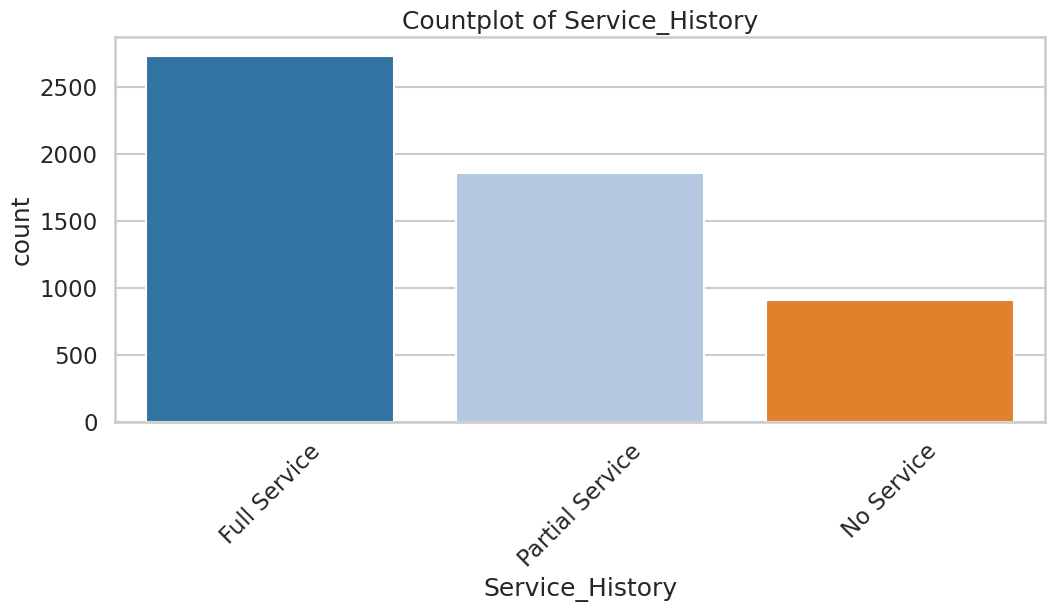

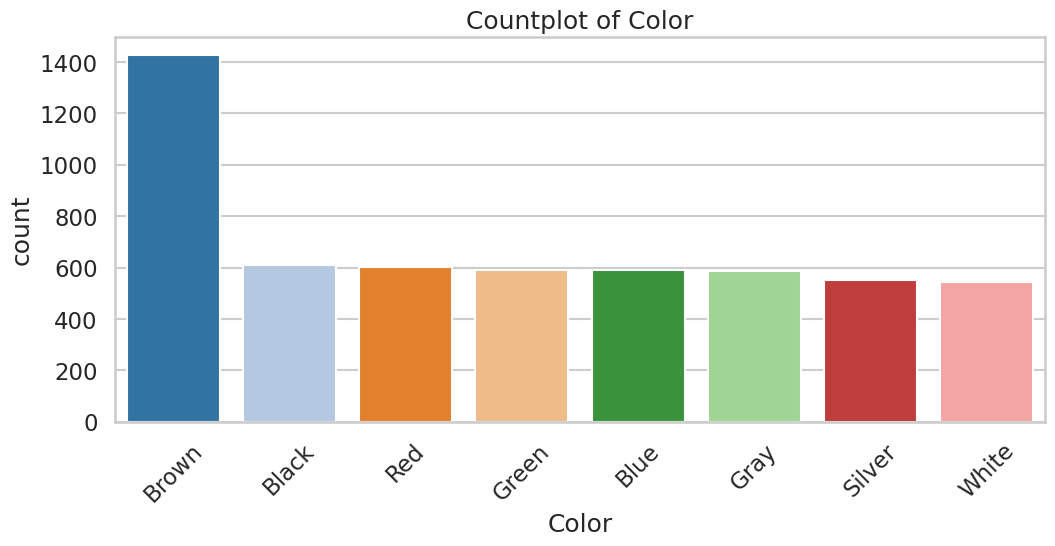

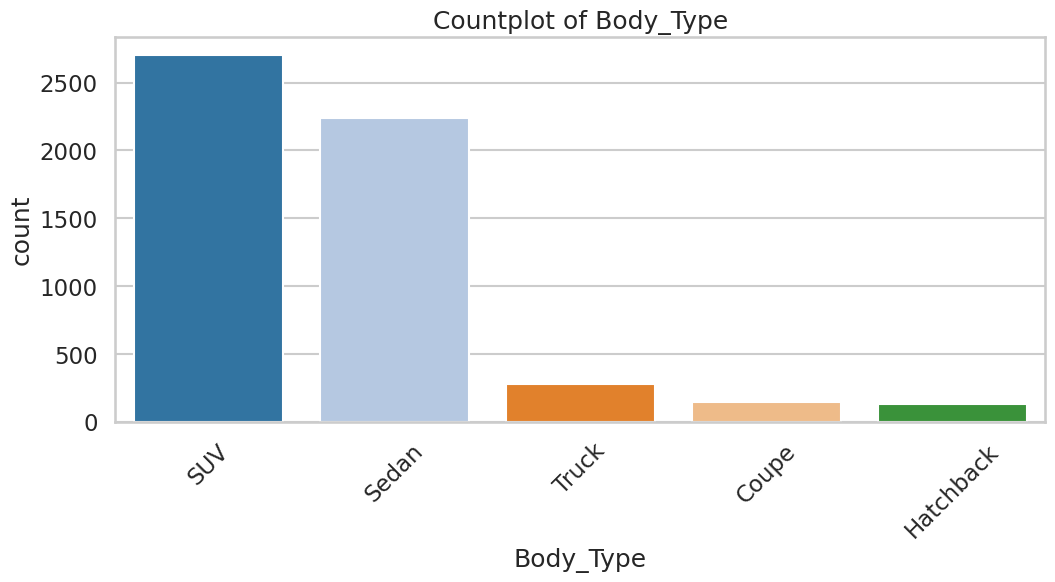

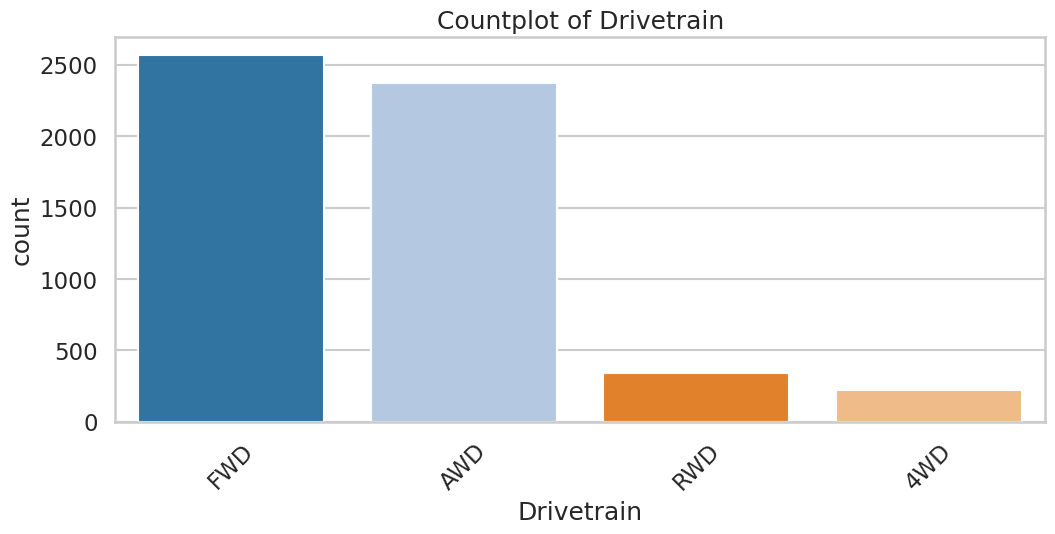

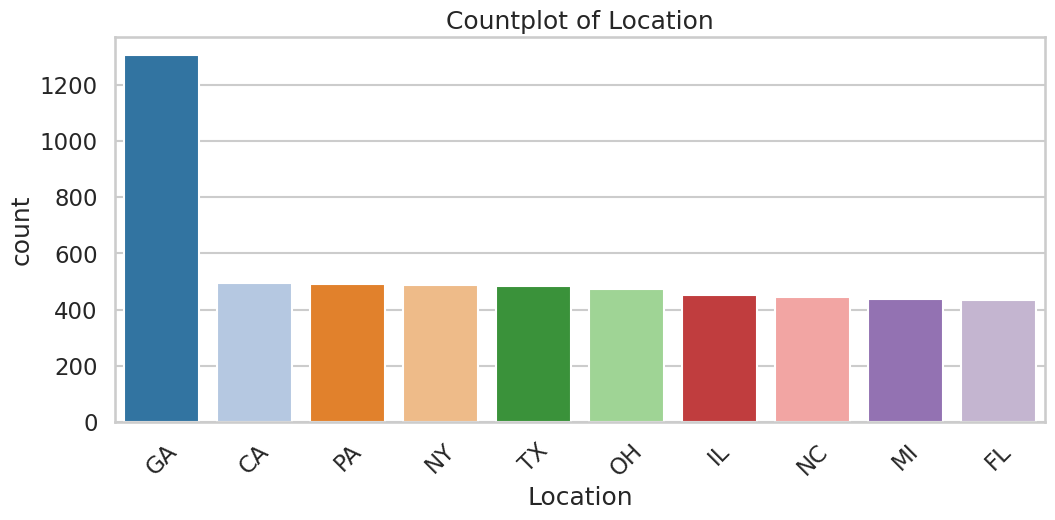

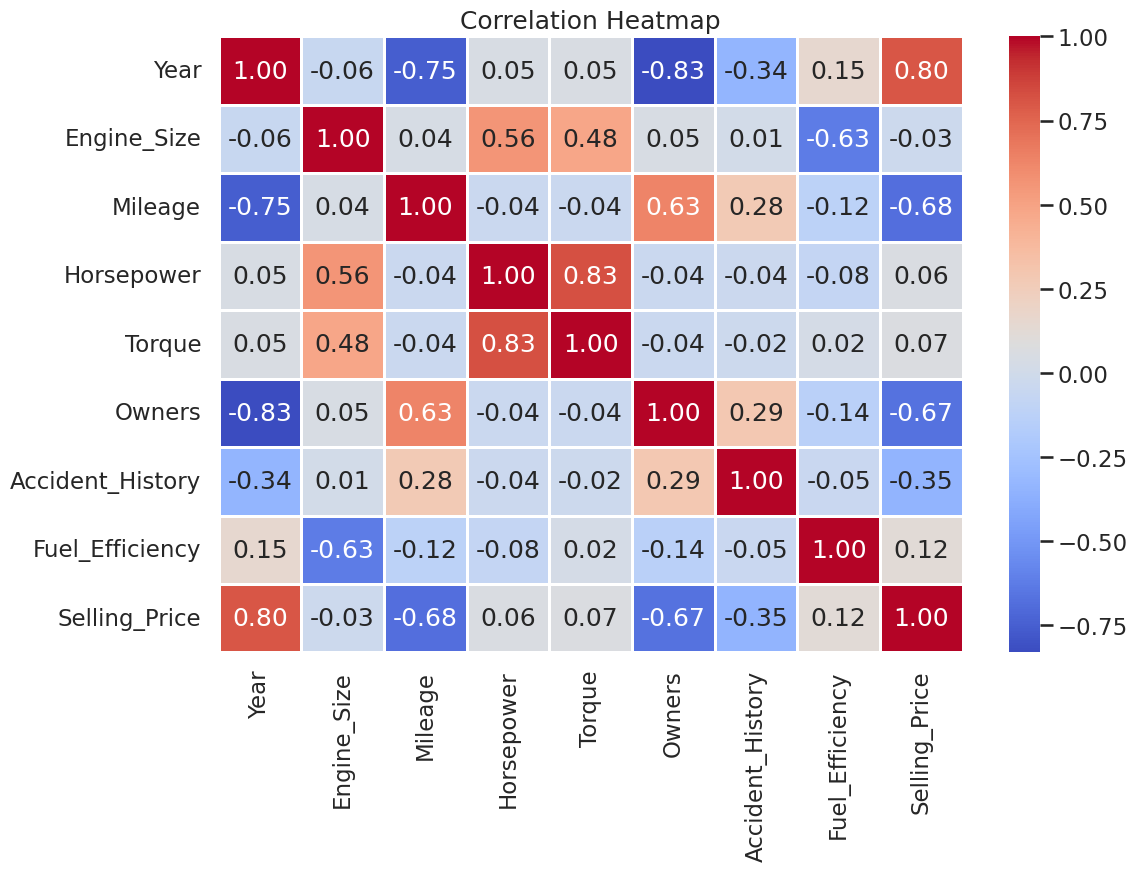

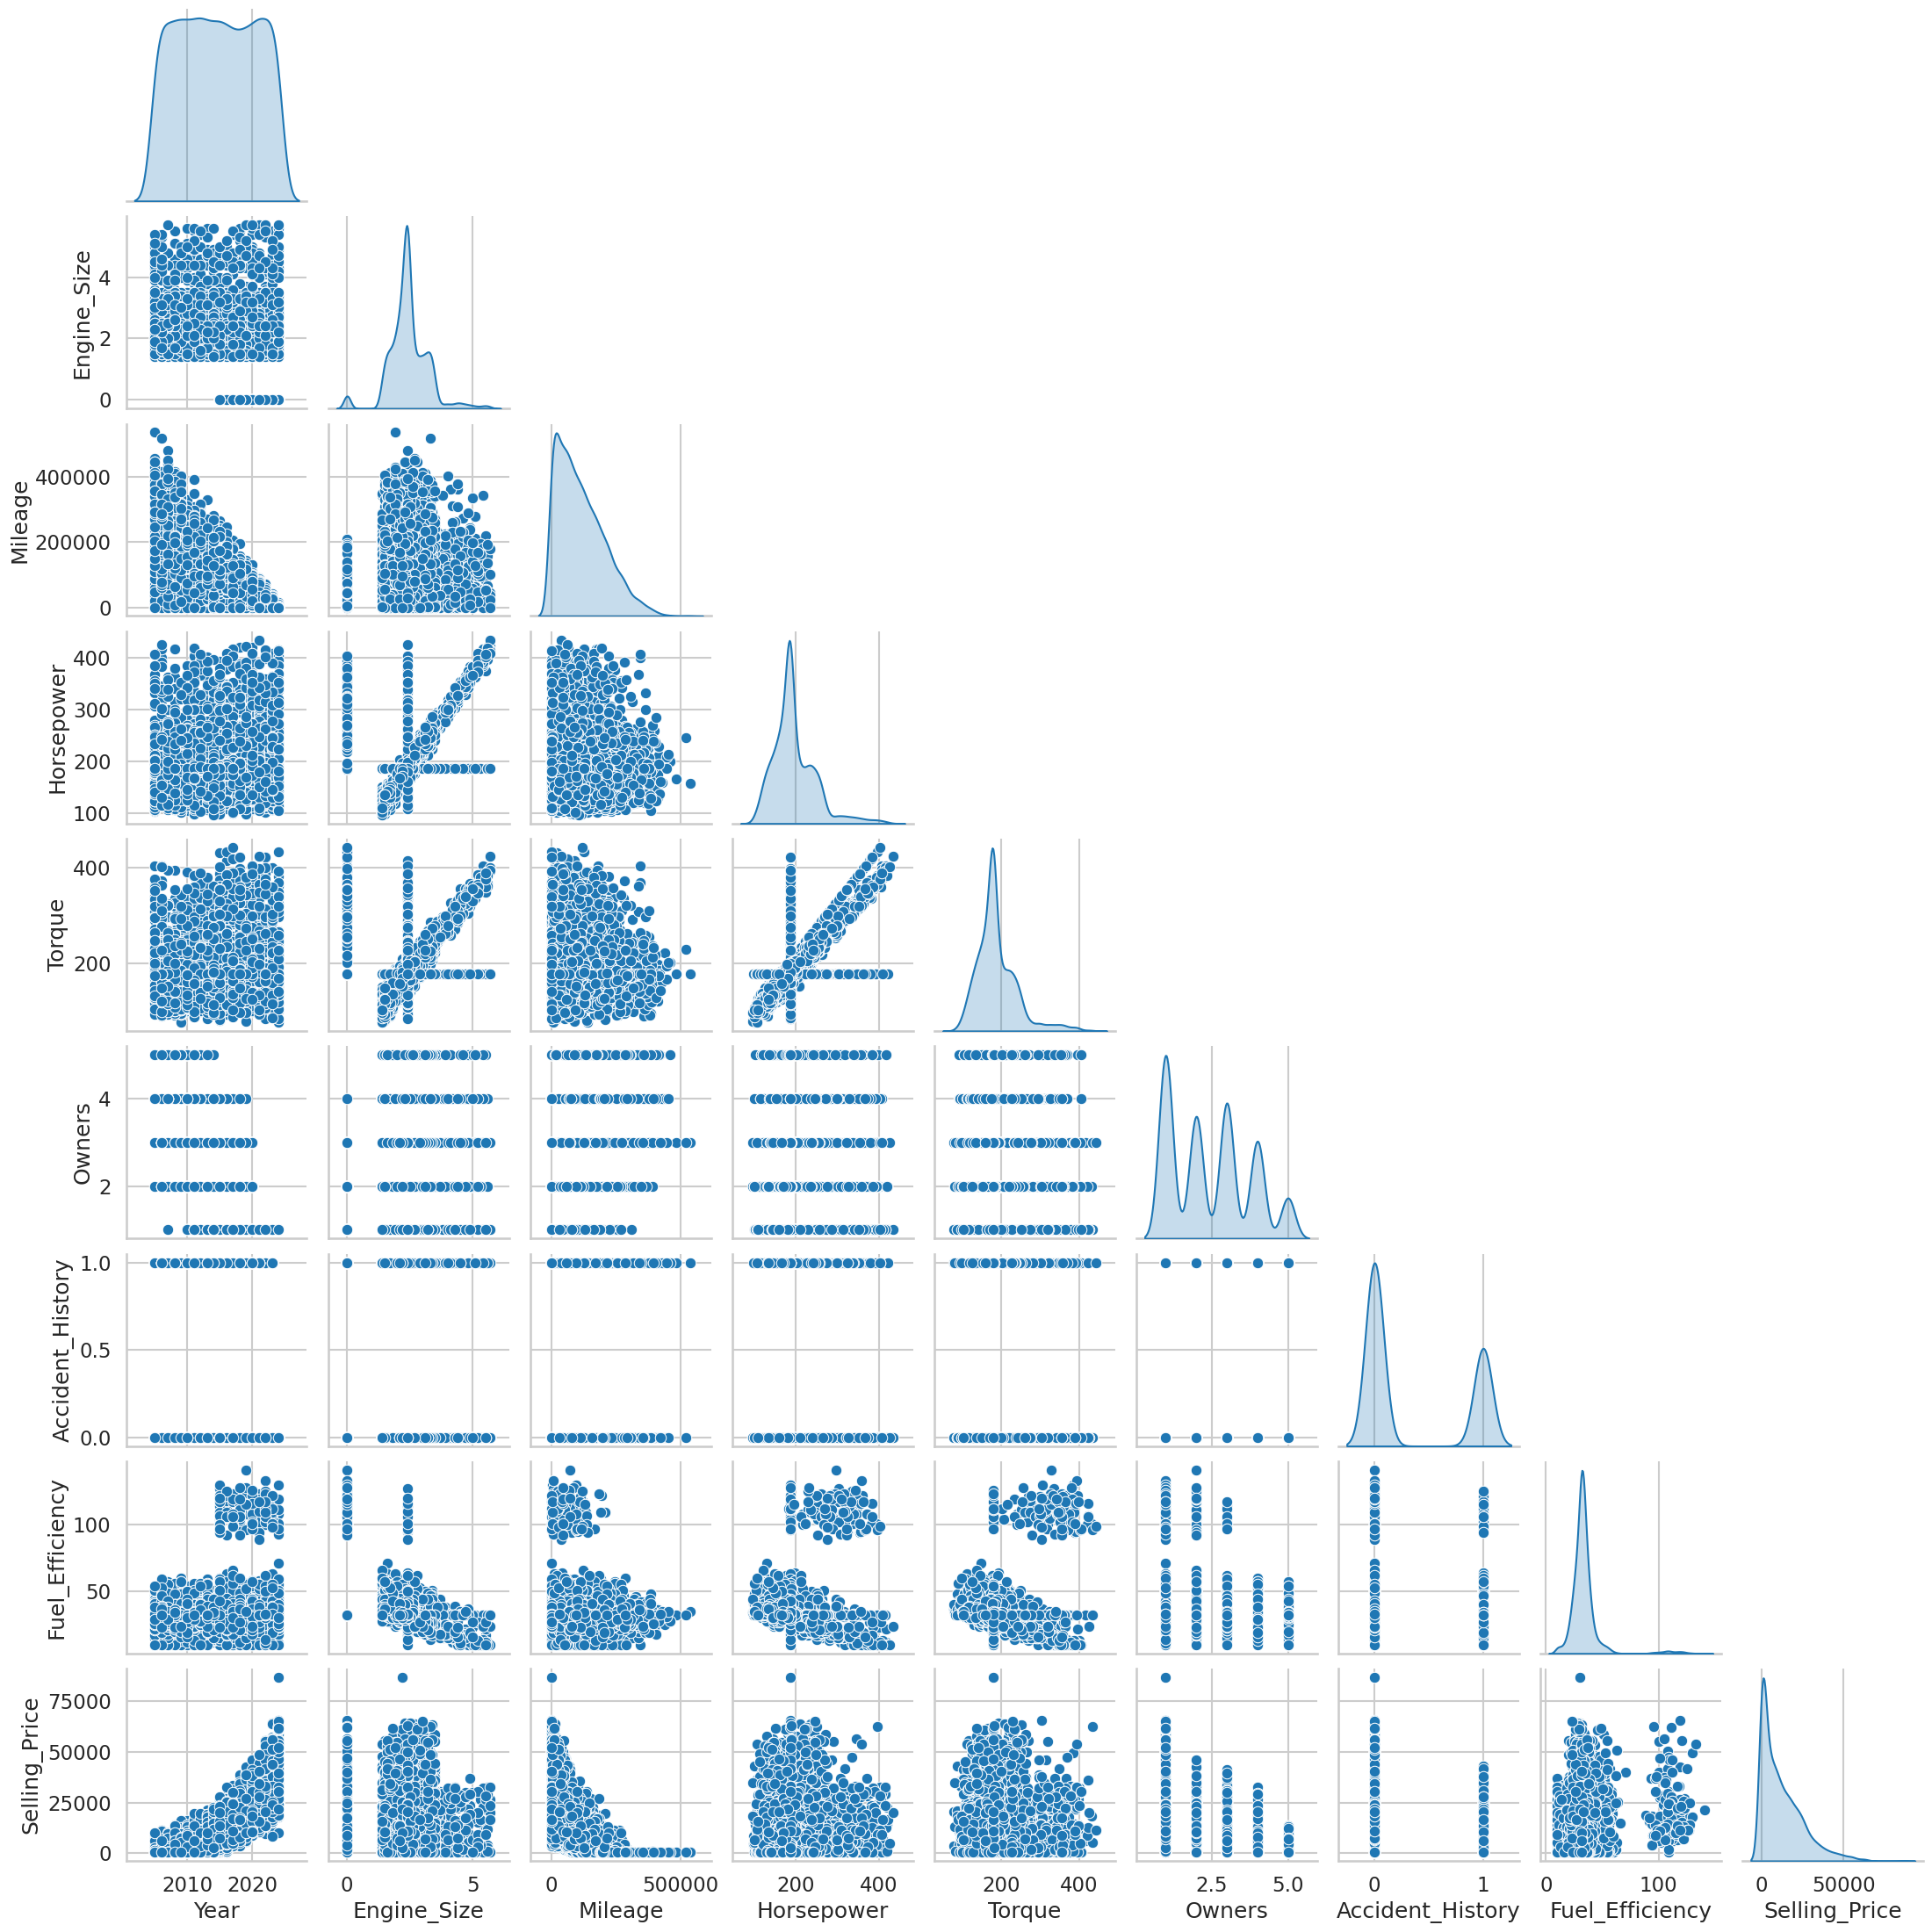

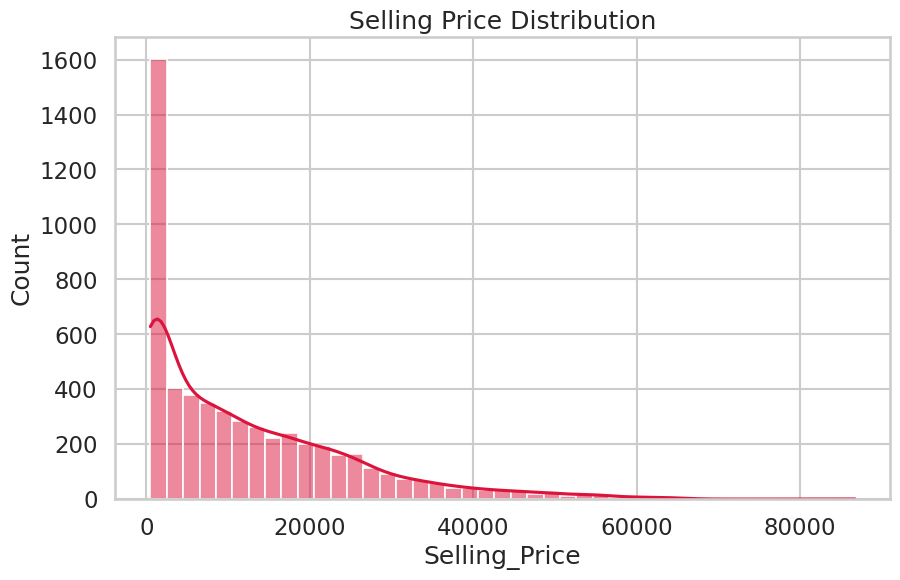

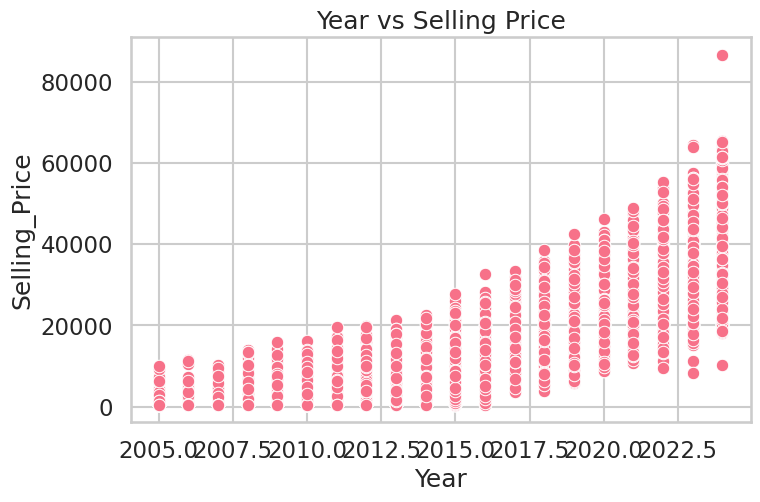

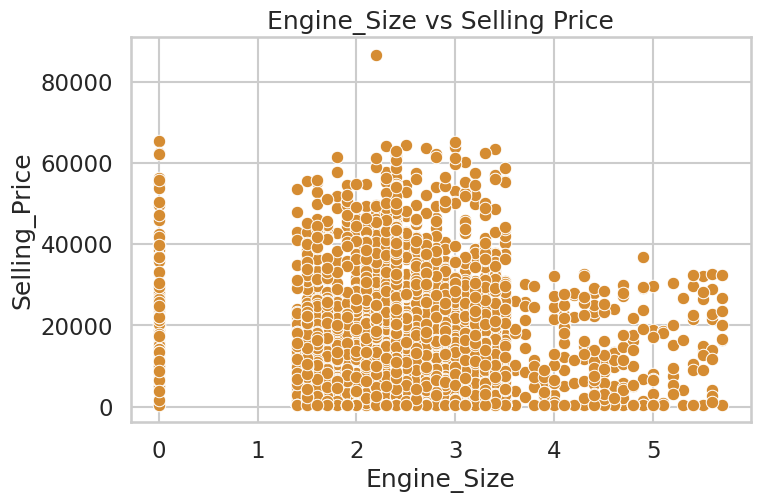

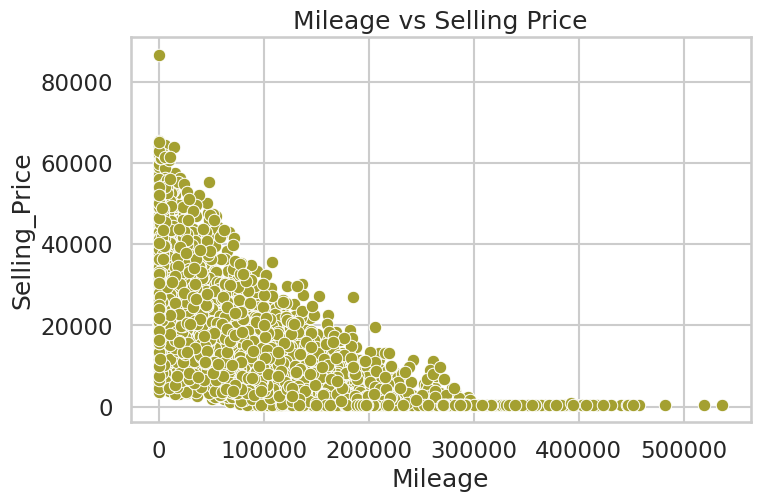

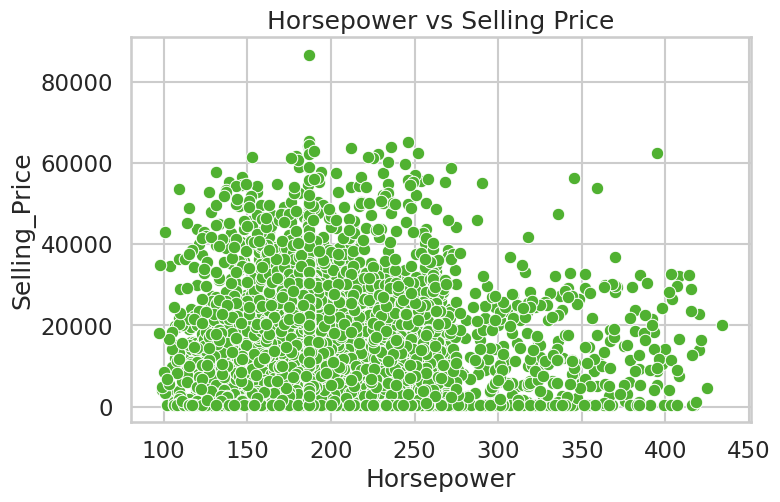

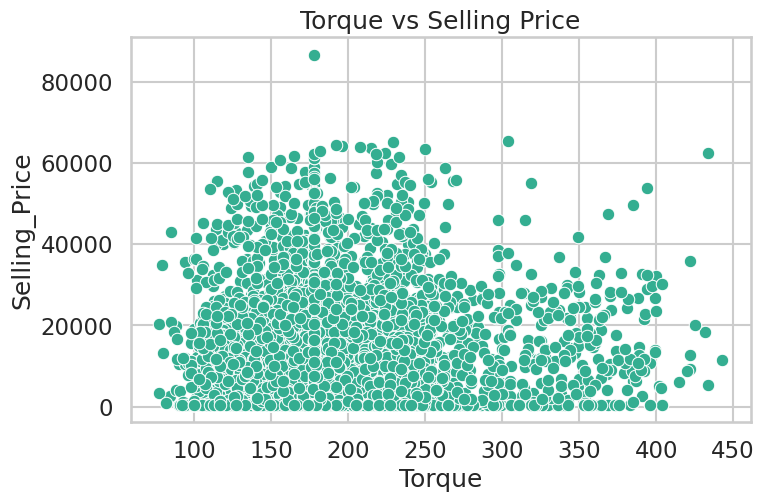

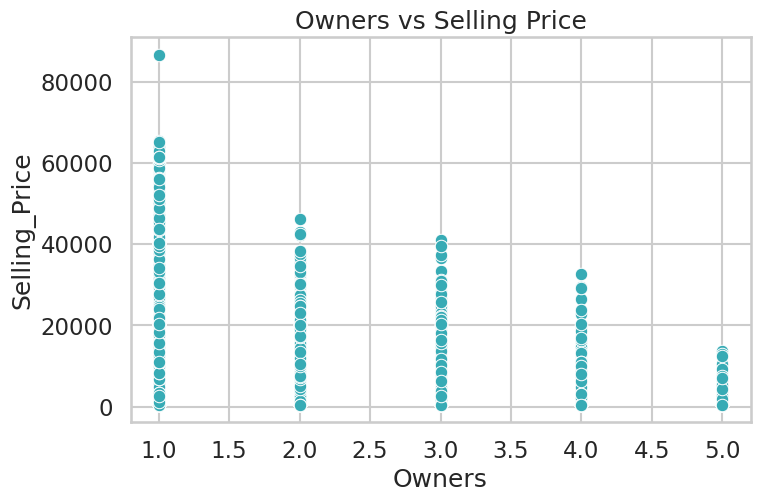

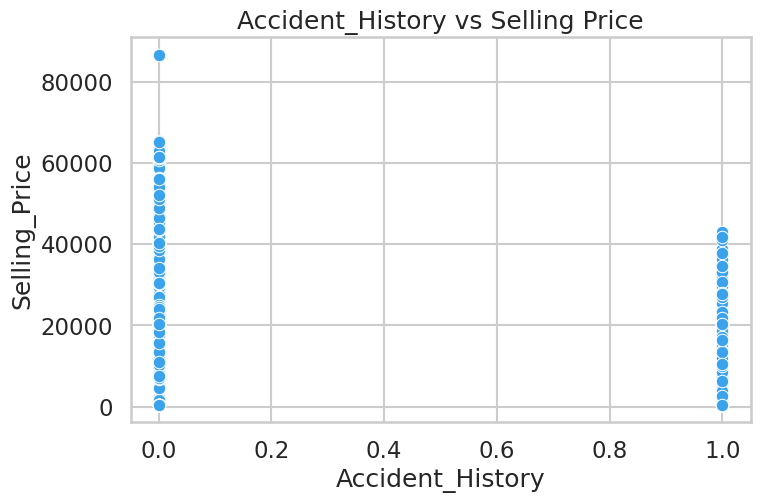

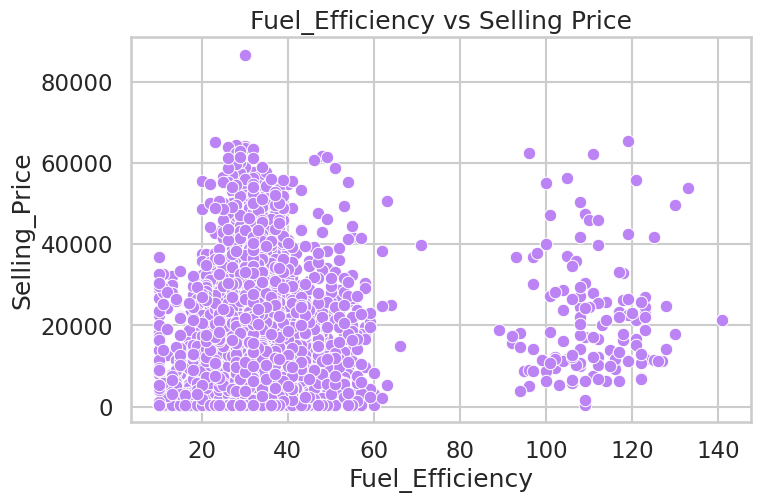

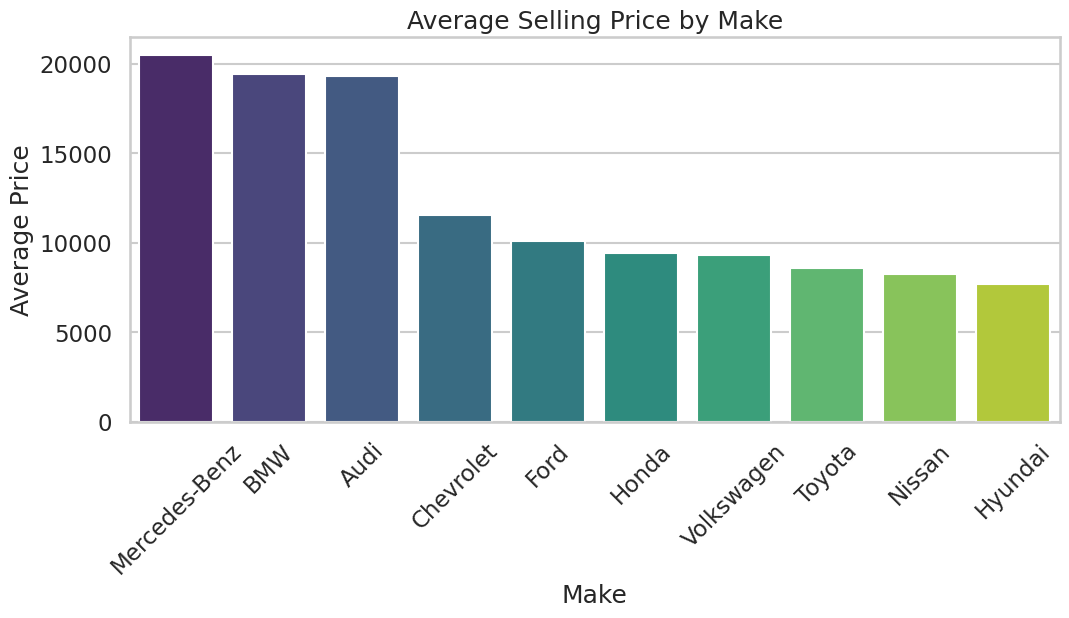

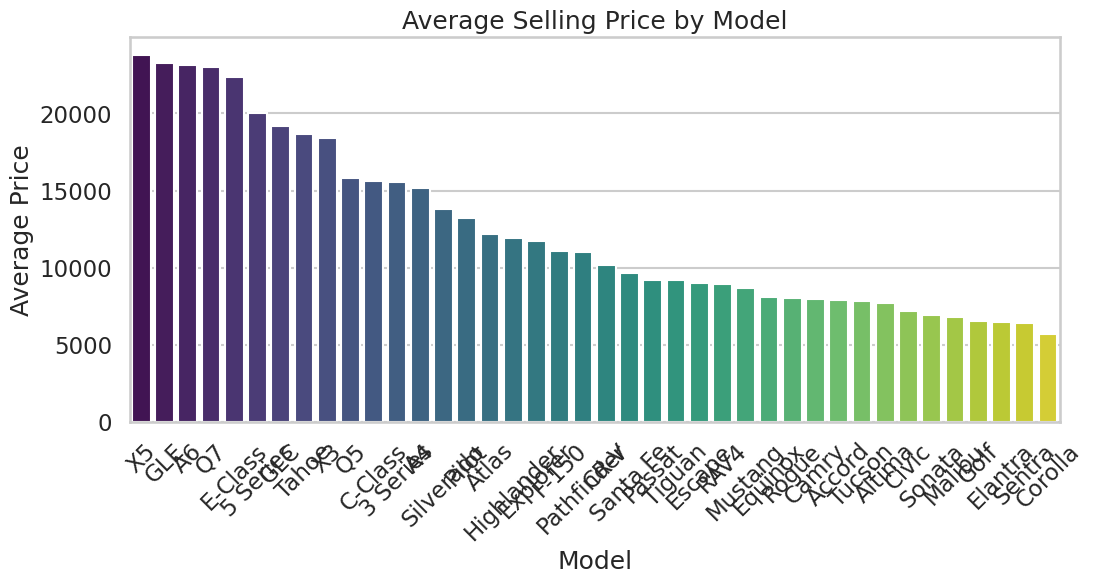

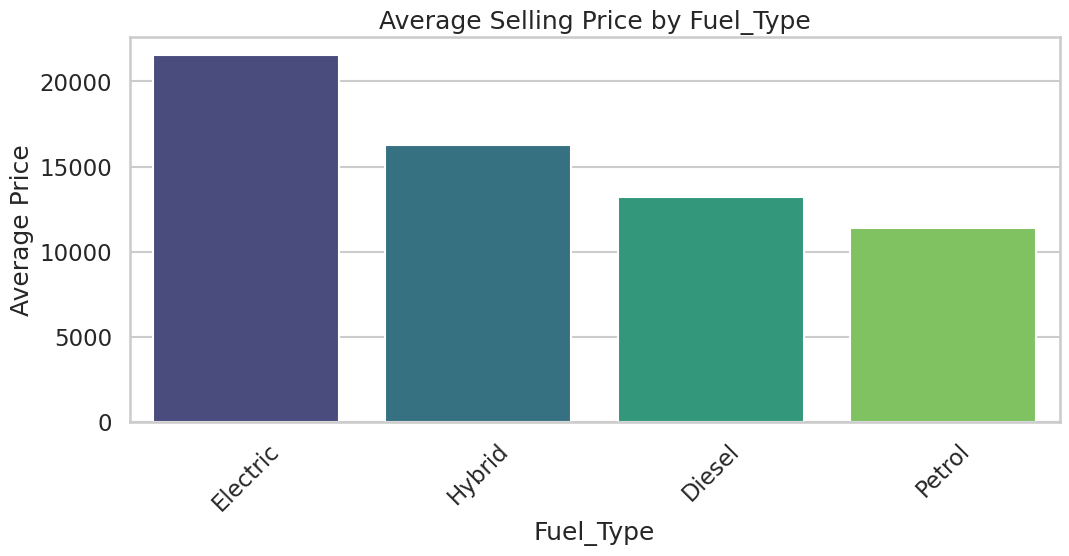

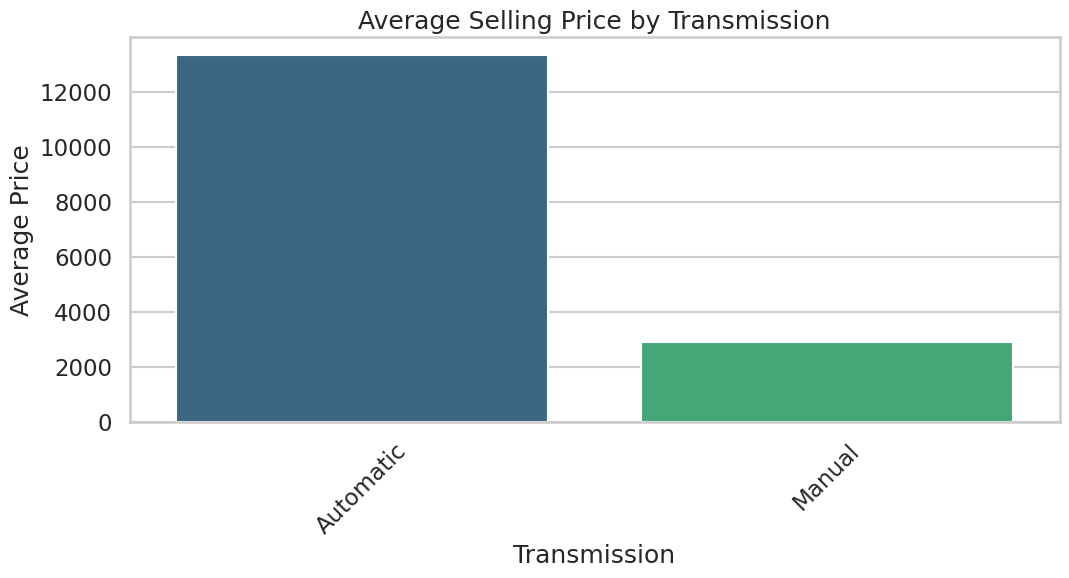

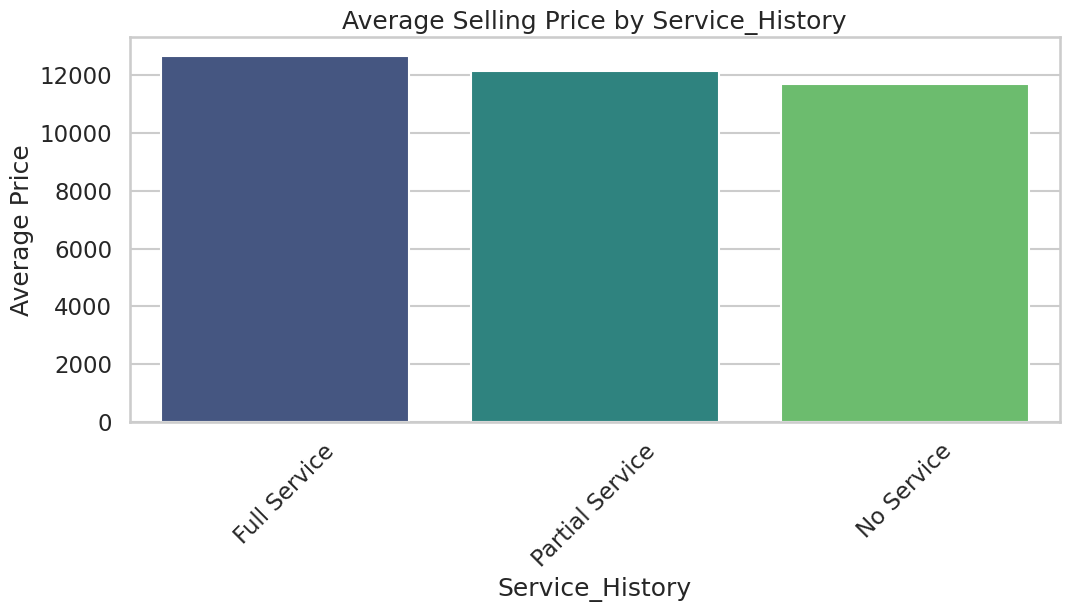

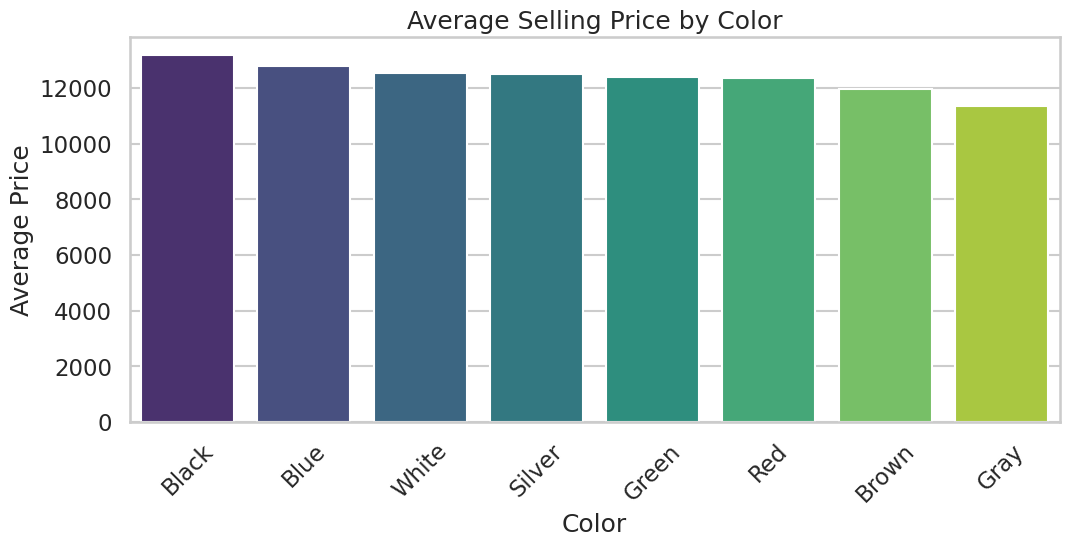

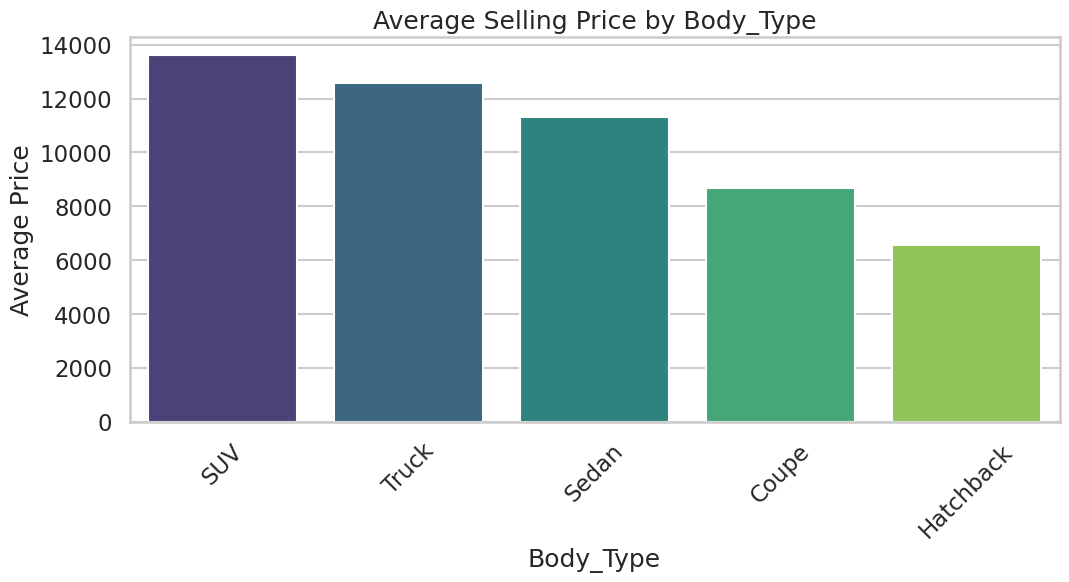

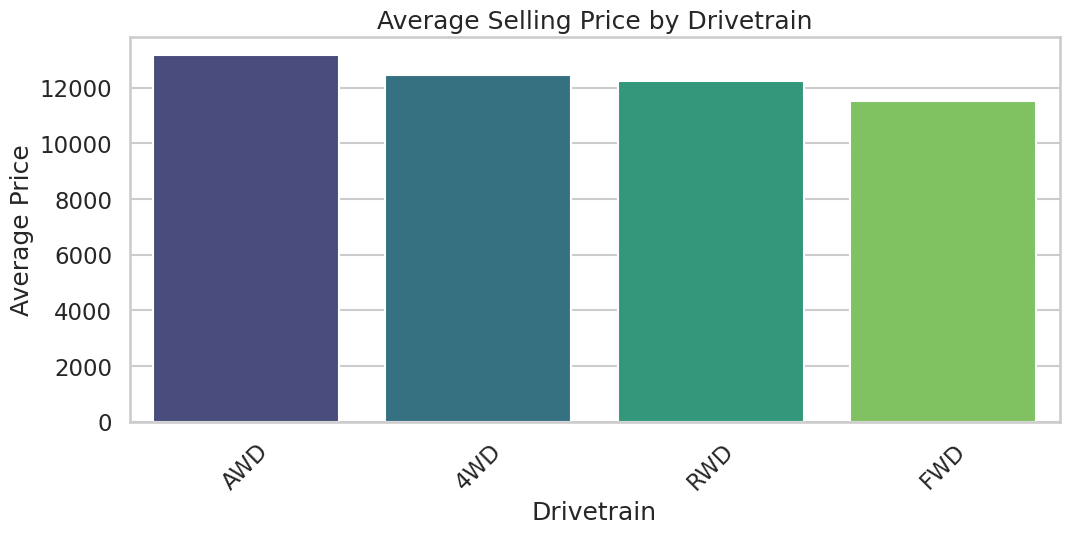

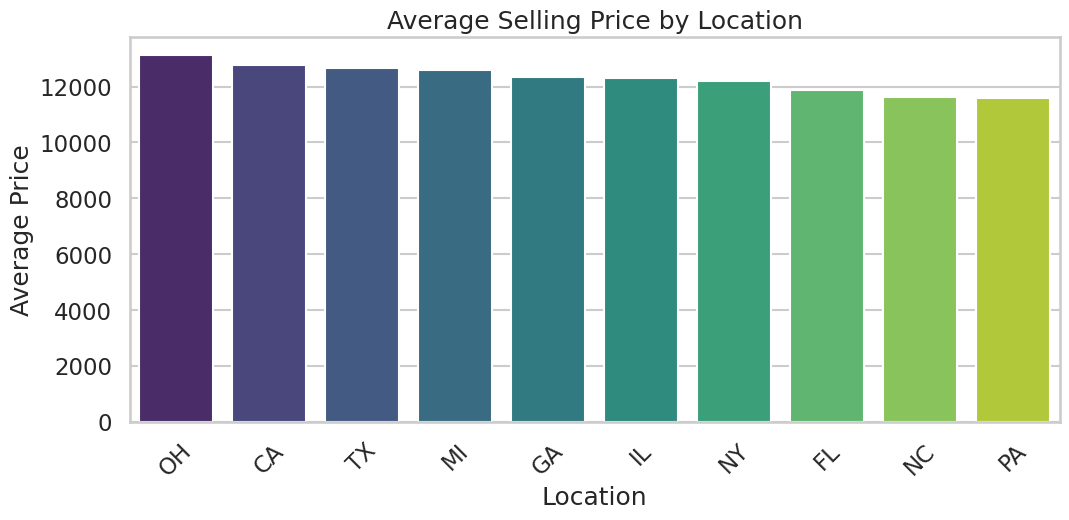

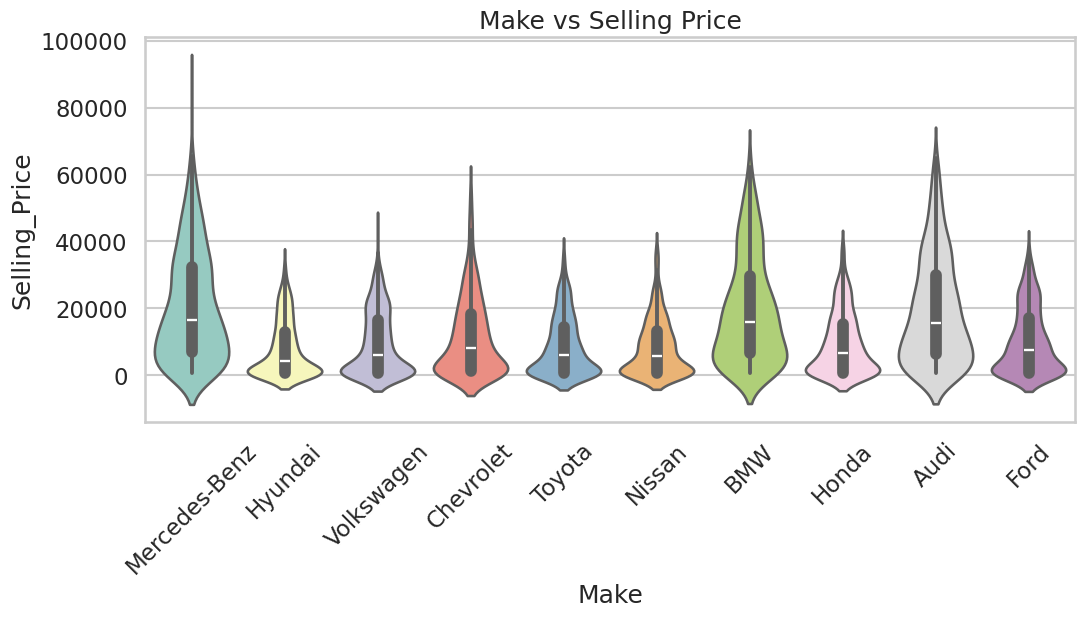

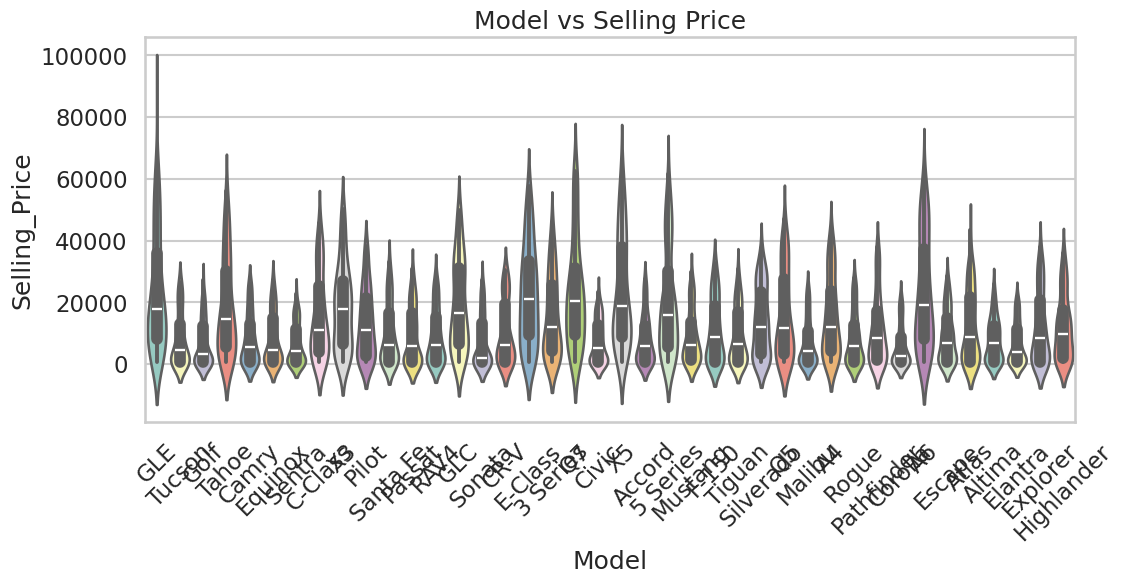

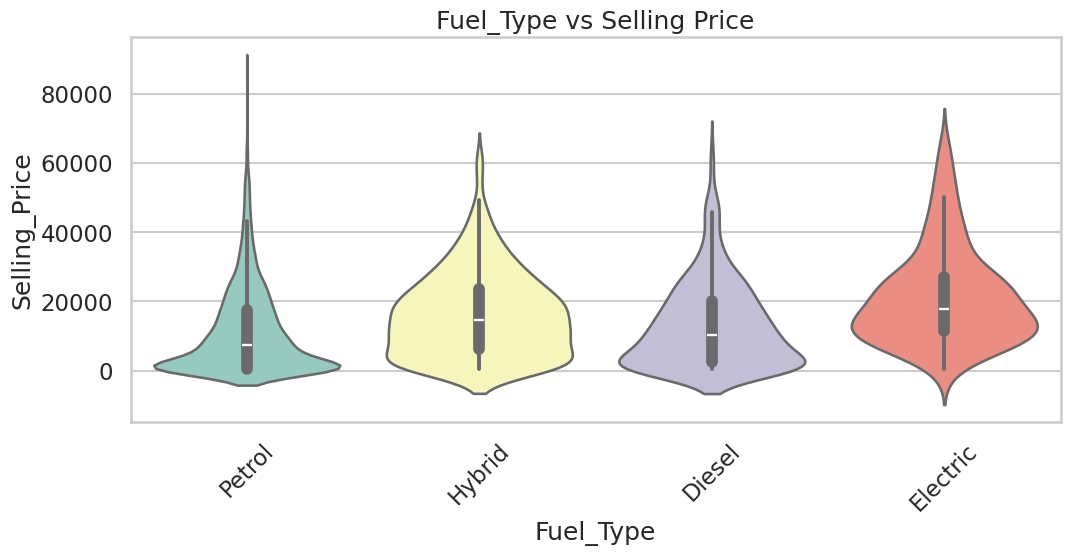

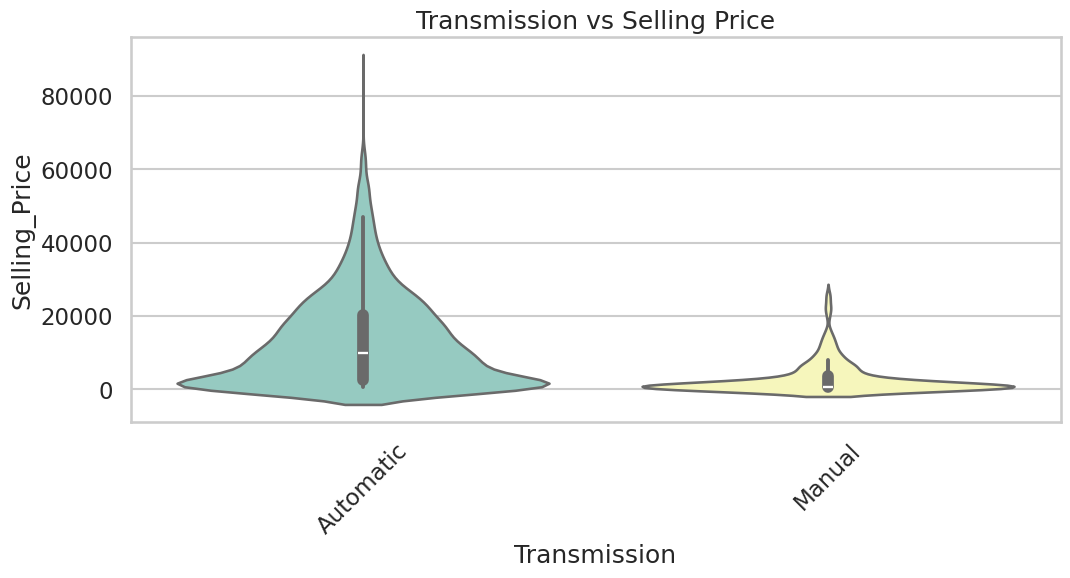

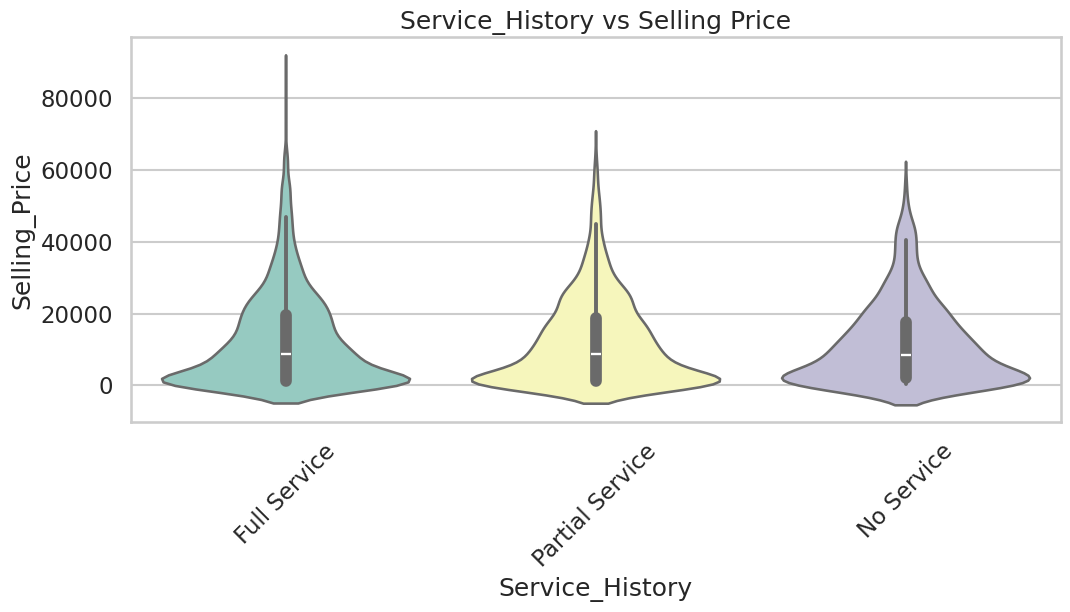

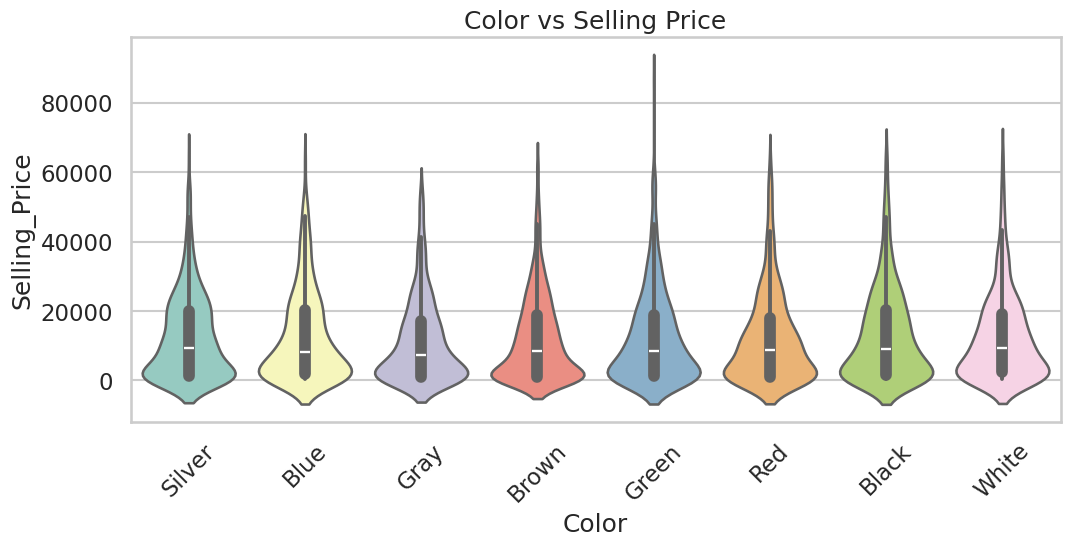

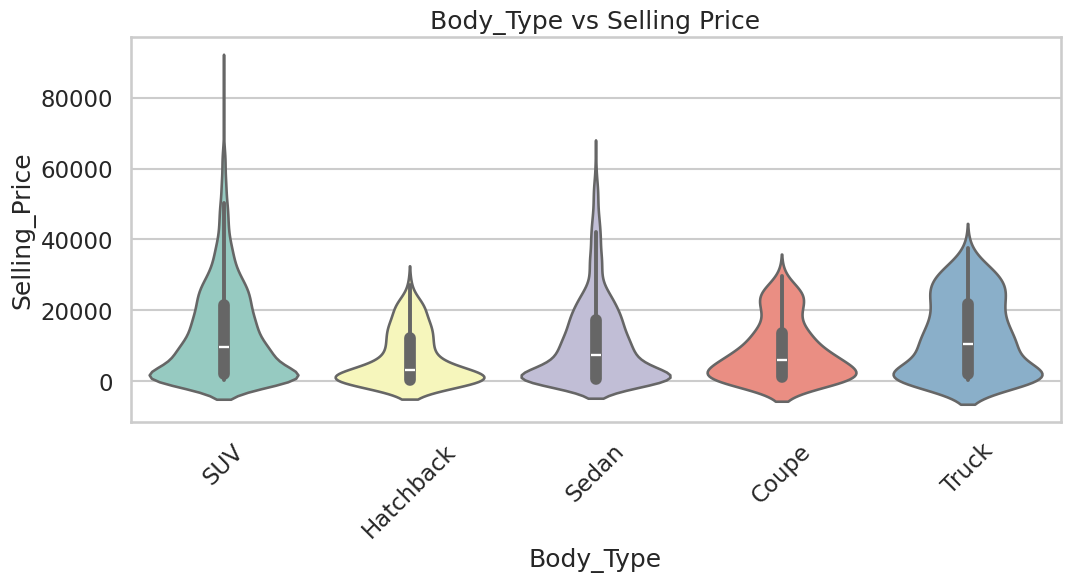

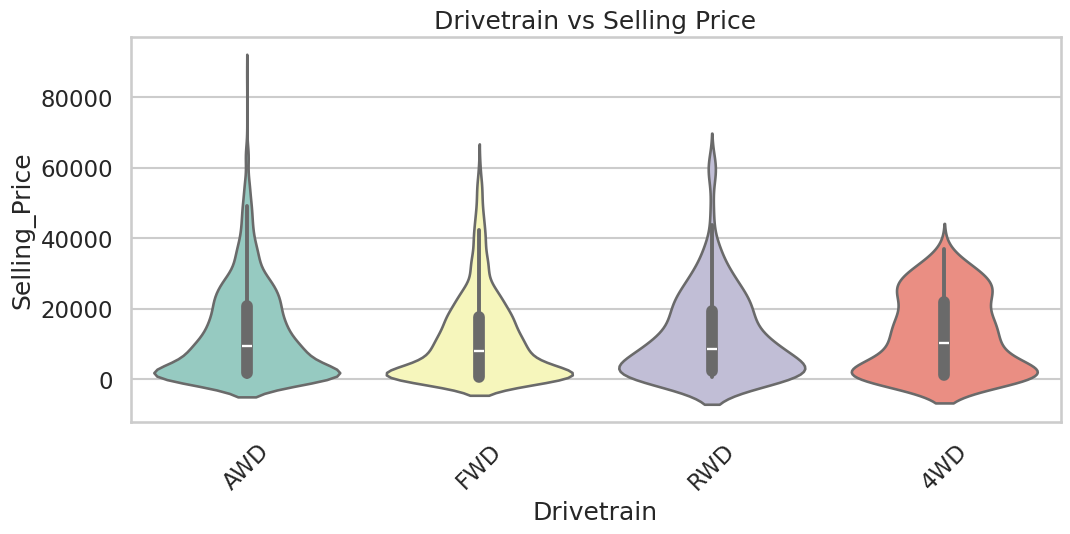

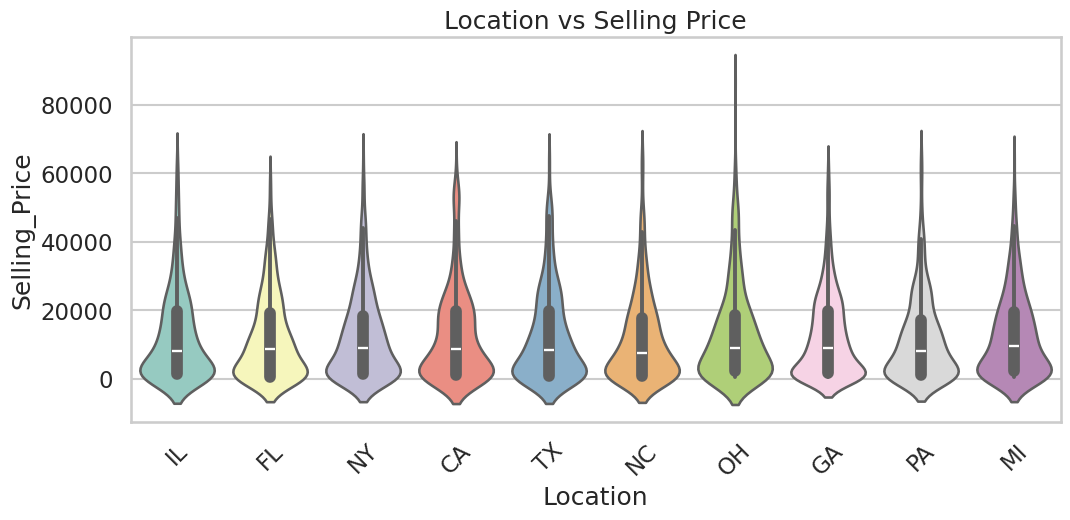

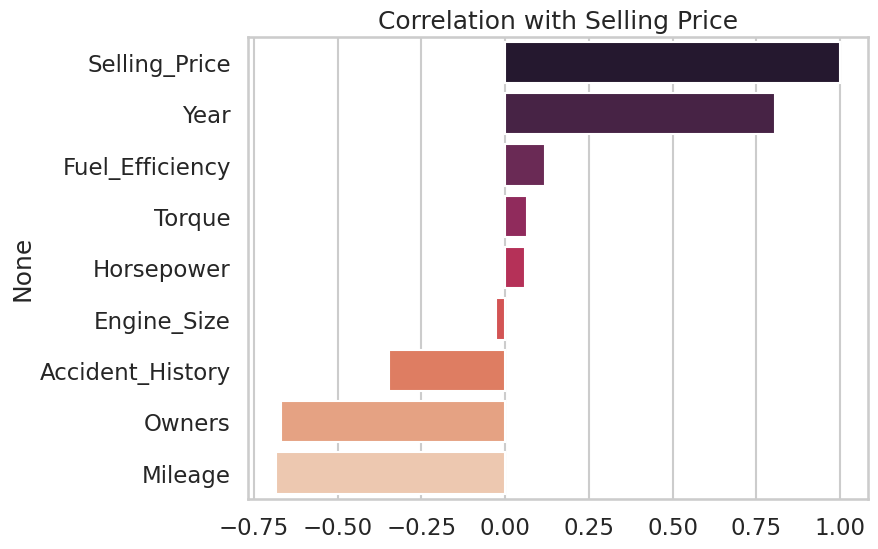

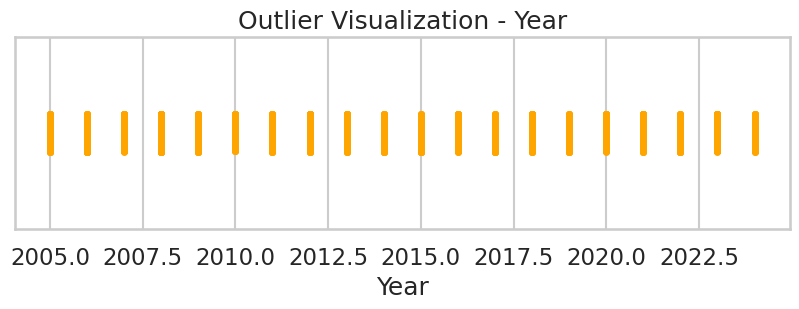

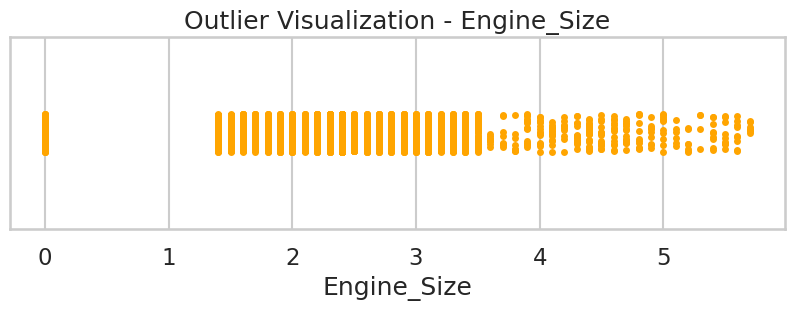

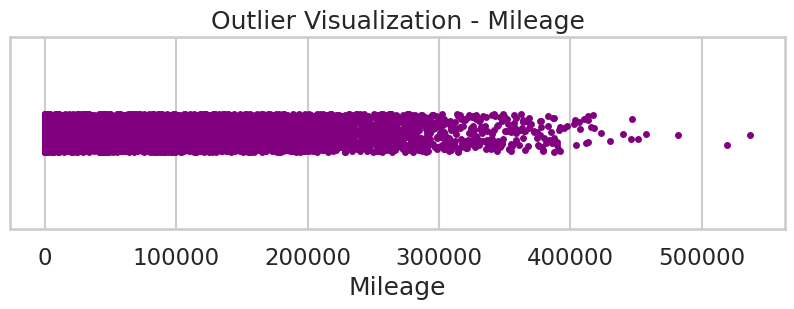

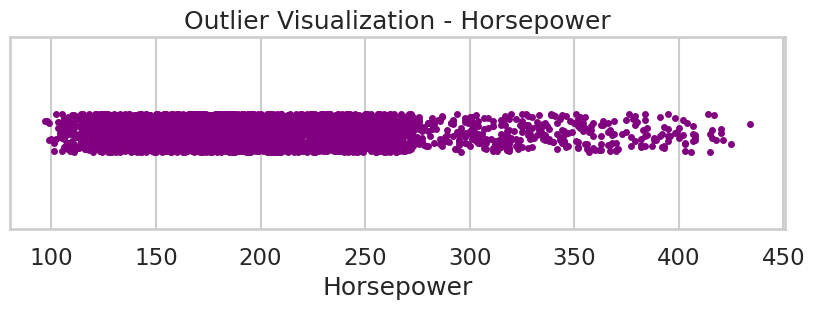

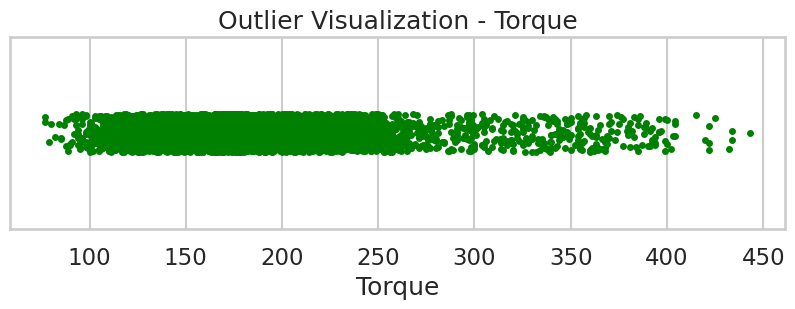

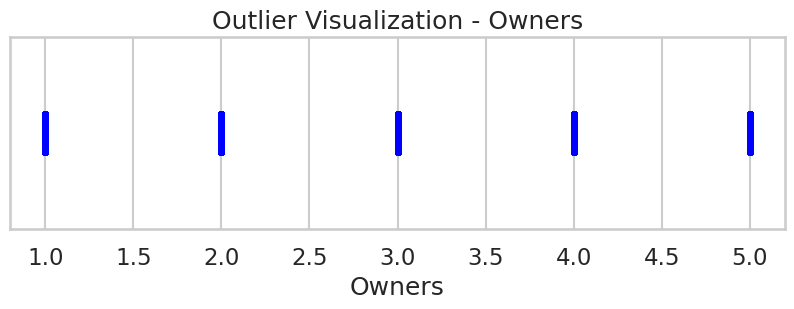

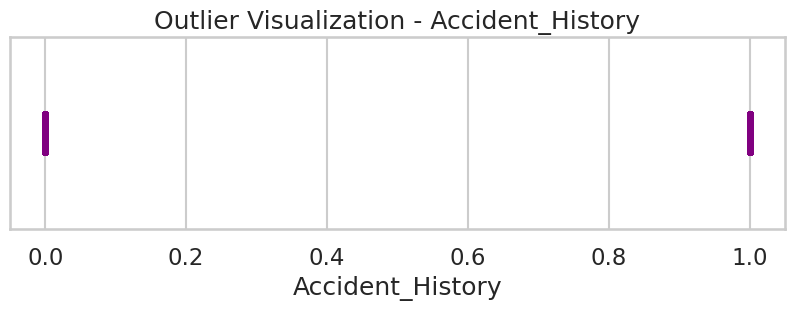

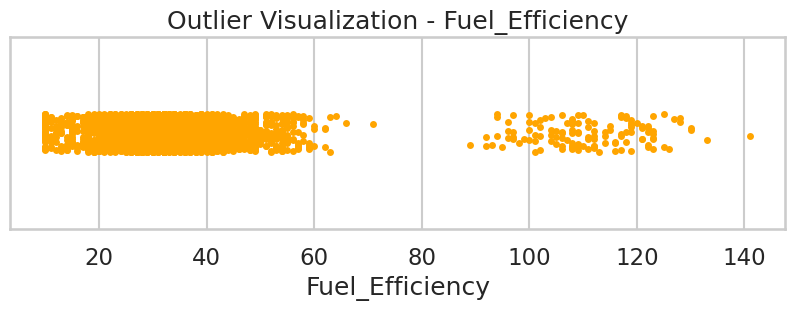

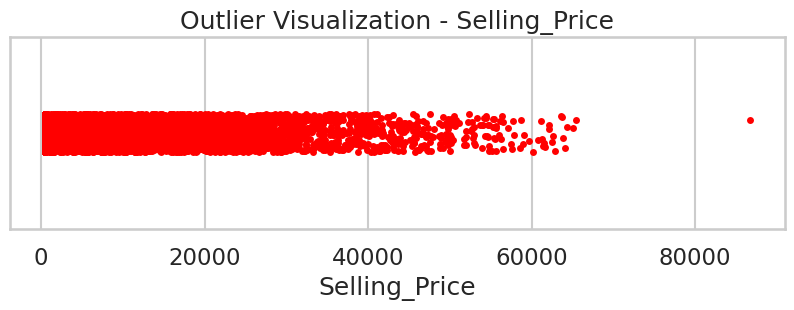



UNIQUE VALUES

Make
Make
Hyundai          579
Ford             579
Volkswagen       569
Chevrolet        556
Honda            553
Nissan           542
Mercedes-Benz    541
Toyota           531
Audi             528
BMW              522
Name: count, dtype: int64

Model
Model
GLE           166
Elantra       163
Passat        156
Malibu        156
Civic         156
Explorer      153
Silverado     152
Santa Fe      150
Escape        150
A4            149
Mustang       149
Tiguan        148
Sentra        146
5 Series      142
Rogue         140
RAV4          140
Q7            138
Accord        137
Atlas         136
Sonata        135
Camry         135
3 Series      134
CR-V          134
GLC           133
Corolla       133
X5            132
E-Class       132
Tucson        131
Pathfinder    129
A6            129
Golf          129
Equinox       128
Altima        127
F-150         127
Pilot         126
Highlander    123
Tahoe         120
X3            114
Q5            112
C-Class       110
Name

In [12]:
# ============================================================
# COMPLETE EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Plot Style
# -------------------------------
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10,6)

# -------------------------------
# Dataset Information
# -------------------------------
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n")
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(df.info())

print("\n")
print("="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())

print("\n")
print("="*60)
print("NUMERICAL DESCRIPTION")
print("="*60)
print(df.describe())

print("\n")
print("="*60)
print("CATEGORICAL DESCRIPTION")
print("="*60)
print(df.describe(include='object'))

# -------------------------------
# Numerical & Categorical Columns
# -------------------------------
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# ============================================================
# Missing Values Heatmap
# ============================================================

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.show()

# ============================================================
# Histograms
# ============================================================

colors = ['red','blue','green','purple','orange',
          'brown','cyan','magenta','gold','olive']

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color=colors[i%len(colors)]
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# ============================================================
# Boxplots
# ============================================================

palette=sns.color_palette("Set2",len(num_cols))

for i,col in enumerate(num_cols):

    plt.figure(figsize=(10,2.5))

    sns.boxplot(
        x=df[col],
        color=palette[i]
    )

    plt.title(f"Boxplot of {col}")
    plt.show()

# ============================================================
# KDE Plots
# ============================================================

palette=sns.color_palette("Dark2",len(num_cols))

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        df[col],
        fill=True,
        color=palette[i]
    )

    plt.title(f"KDE Plot - {col}")
    plt.show()

# ============================================================
# Countplots
# ============================================================

for col in cat_cols:

    plt.figure(figsize=(12,5))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        palette="tab20"
    )

    plt.xticks(rotation=45)

    plt.title(f"Countplot of {col}")

    plt.show()

# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(12,8))

corr=df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# Pairplot
# ============================================================

sns.pairplot(
    df[num_cols],
    corner=True,
    diag_kind="kde"
)

plt.show()

# ============================================================
# Selling Price Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Selling_Price"],
    kde=True,
    color="crimson"
)

plt.title("Selling Price Distribution")

plt.show()

# ============================================================
# Scatterplots
# ============================================================

palette=sns.color_palette("husl",len(num_cols))

for i,col in enumerate(num_cols):

    if col!="Selling_Price":

        plt.figure(figsize=(8,5))

        sns.scatterplot(
            data=df,
            x=col,
            y="Selling_Price",
            color=palette[i]
        )

        plt.title(f"{col} vs Selling Price")

        plt.show()

# ============================================================
# Average Selling Price by Category
# ============================================================

for col in cat_cols:

    temp=df.groupby(col)["Selling_Price"].mean().sort_values(ascending=False)

    plt.figure(figsize=(12,5))

    sns.barplot(
        x=temp.index,
        y=temp.values,
        palette="viridis"
    )

    plt.xticks(rotation=45)

    plt.title(f"Average Selling Price by {col}")

    plt.ylabel("Average Price")

    plt.show()

# ============================================================
# Violin Plots
# ============================================================

for col in cat_cols:

    plt.figure(figsize=(12,5))

    sns.violinplot(
        data=df,
        x=col,
        y="Selling_Price",
        palette="Set3"
    )

    plt.xticks(rotation=45)

    plt.title(f"{col} vs Selling Price")

    plt.show()

# ============================================================
# Correlation with Target
# ============================================================

corr_target=df.corr(numeric_only=True)["Selling_Price"].sort_values(ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    palette="rocket"
)

plt.title("Correlation with Selling Price")

plt.show()

# ============================================================
# Outlier Detection using Strip Plot
# ============================================================

for col in num_cols:

    plt.figure(figsize=(10,2.5))

    sns.stripplot(
        x=df[col],
        color=np.random.choice(['red','green','blue','purple','orange'])
    )

    plt.title(f"Outlier Visualization - {col}")

    plt.show()

# ============================================================
# Print Unique Values
# ============================================================

print("\n")
print("="*60)
print("UNIQUE VALUES")
print("="*60)

for col in cat_cols:

    print(f"\n{col}")
    print(df[col].value_counts())

print("\n")
print("="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)

## Thanks.......Please Upvote